In [1]:
! which python

'which' is not recognized as an internal or external command,
operable program or batch file.


# Homework 4
   
 - All questions must be answered in your own words, do not copy-paste text from the internet. Points can be deducted for terrible formatting or incomprehensible English.

 - Code must be commented. If you use code you found online, you have to add the link to the source you used. There is no penalty for using outside sources as long as you convince us you understand the code.

  **To pass the homework you need to attempt to do all tasks. If we see that you misunderstand some concept, you may receive personal feedback and you can have a chance to resubmit your homework.**
 **Please treat these homeworks as learning opportunities to support your study! Instead of copy-pasting solution, attempt to do it yourself and rather learn from feedback**

**You can earn up to 5 bonus points by tuning the hyperparameters and reaching test accuracies above 52%**

*Once completed zip the entire directory containing this exercise and upload it to Moodle.
   
For background reading see http://cs231n.github.io/optimization-2/  
http://vision.stanford.edu/teaching/cs231n/handouts/derivatives.pdf  
https://web.stanford.edu/class/cs224n/readings/gradient-notes.pdf



## Applied Theory

In this exercise we have a neural network with one hidden layer. This time we derive gradients slightly differently:
1. we use batch of samples instead of one sample,
2. **we use matrix calculus for gradients,**
3. we add L2 regularization to the loss.

![alt text][logo]

[logo]: http://cs231n.github.io/assets/nn1/neural_net.jpeg "Logo Title Text 2"


Notation:
 * $\mathbf{X}$ is $N \times D$ input matrix, where $N$ is number of samples in batch and $D$ is number of features.
 * $\mathbf{Y}$ is $N \times C$ one-hot coded target matrix, where $N$ is number of samples in batch and $C$ is number of classes.
 * $\mathbf{c}$ is $N$-dimensional vector of correct classes for all samples, $\mathbf{c}_i \in \{1, \ldots, C\}$.
 * $\mathbf{W}^{(1)}$ is $D \times M$ weight matrix of the first layer, where $D$ is the number of features and $M$ is number of hidden nodes.
 * $\mathbf{W}^{(2)}$ is $M \times C$ weight matrix of the second layer, where $M$ is the number of hidden nodes and $C$ is the number of classes.
 * $\mathbf{b}^{(1)}$ is bias vector of the first layer with dimension of $1 \times M$.
 * $\mathbf{b}^{(2)}$ is bias vector of the second layer with dimension of $1 \times C$.
 * $1_N$ is a column vector of ones of length N with dimension $N \times 1$
 * $\text{ReLU}(x) = \max(x, 0)$ is rectified linear unit activation function.
 * $\mathbf{P} = \text{softmax}(\mathbf{A})$ converts activations into probabilities row by row $\mathbf{P}_{ij} = \frac{e^ {\mathbf{A}_{ij}}}{\sum_k e^{\mathbf{A}_{ik}}}$.



**Feed-forward pass:**
$$
\begin{align*}
\mathbf{A}^{(1)} &= \mathbf{X} \mathbf{W}^{(1)} + 1_N \mathbf{b}^{(1)}   &(N\times M)
\\
\mathbf{H}^{(1)} &= \text{ReLU}(\mathbf{A}^{(1)}) &(N\times M)
\\
\mathbf{A}^{(2)} &= \mathbf{H}^{(1)} \mathbf{W}^{(2)} + 1_N \mathbf{b}^{(2)} &(N\times C)
\\
\mathbf{P} &= \text{softmax}(\mathbf{A}^{(2)}) &(N\times C)
\\
L_{CE} &= -\frac{1}{N} \sum_{i=1}^{N} \mathbf{Y}_{i\cdot} \odot \log \mathbf{P}_{i\cdot} = 
-\frac{1}{N} \sum_{i=1}^{N} \log \mathbf{P}_{i\mathbf{c}_i}   &(\text{scalar})
\end{align*}
$$

Here $AB$ is matrix multiplication and $A\odot B$ is element-wise multiplication.  
$\frac{1}{N}$ in the loss function produces mean instance loss, which is good because then loss value does not depend on batch size. If we had used sum, both loss value and gradients would have different magnitude for different batch sizes and we would need to adapt learning rate for each batch size.

<br><br>
**Backward pass:**  
Derivatives of matrix multiplication work very similarly to the scalar case. However, as the order of elements in product matters (AB $\neq$ BA), pay attention to transposes and also on which side of the overall expression the derviative ends up. Suppose  
  $$ L = f(Y),\qquad Y = XW.$$
Then
\begin{align*}
\frac{\partial L}{\partial X} &=  \frac{\partial L}{\partial Y} \frac{\partial Y}{\partial X}= \frac{\partial L}{\partial Y} \frac{\partial XW}{\partial X} =\frac{\partial L}{\partial Y} W^T\\
\frac{\partial L}{\partial W} &= \frac{\partial L}{\partial Y} \frac{\partial Y}{\partial W}= \frac{\partial L}{\partial Y} \frac{\partial XW}{\partial W} = X^T  \frac{\partial L}{\partial Y}.
\end{align*}
Notice that the multiplication with transposed matrix is from different sides in these two cases.

Backward pass for $\mathbf{W}^{(1)}$ using chain rule:
\begin{align*}
    \frac{\partial L_{CE}}{\partial\mathbf{W}^{(1)}} &= \frac{\partial L_{CE}}{\partial\mathbf{A}^{(1)}}\frac{\partial \mathbf{A}^{(1)}}{\partial\mathbf{W}^{(1)}} & \text{(chain rule)}\\
    &= X^T\frac{\partial L_{CE}}{\partial\mathbf{A}^{(1)}} & \text{(previous formula)}\\
    &= X^T\frac{\partial L_{CE}}{\partial\mathbf{H}^{(1)}}\frac{\partial\mathbf{H}^{(1)}}{\partial\mathbf{A}^{(1)}} & \text{(chain rule)}\\
    &= X^T\left(\frac{\partial L_{CE}}{\partial\mathbf{H}^{(1)}}\odot(\mathbf{A}^{(1)}>0)\right)\\
    &= X^T\left(\frac{\partial L_{CE}}{\partial\mathbf{A}^{(2)}}\frac{\partial\mathbf{A}^{(2)}}{\partial\mathbf{H}^{(1)}}\odot(\mathbf{A}^{(1)}>0)\right)&\text{(chain rule)}\\
    &= X^T\left(\left(\frac{\partial L_{CE}}{\partial\mathbf{A}^{(2)}}(\mathbf{W}^{(2)})^T\right)\odot(\mathbf{A}^{(1)}>0)\right)&\text{(previous formula)}\\
    &= \frac{1}{N}X^T\left(\left((P-Y)(\mathbf{W}^{(2)})^T\right)\odot(\mathbf{A}^{(1)}>0)\right)&\text{(from previous practice)}
\end{align*}
Here $(\mathbf{A}^{(1)}>0)$ denotes a matrix whose value at row $i$ and column $j$ is one, if the corresponding value in matrix $\mathbf{A}$ is greater than 0, and 0 otherwise.

Write down the partial derivatives of classification loss function with respect to other weights and biases.

The partial derivatives of classification loss function with respect to other weights and biases adjust the parameters of the artificial neural network.

The resulting shape of the matrices shows the compatibility with the network architecture.

#### **!NB** These partial derivatives will help you to do the tasks below. Verify that the dimensions match!

\begin{align*}
\frac{\partial L_{CE}}{\partial\mathbf{W}^{(2)}} &= . . .
\\
\frac{\partial L_{CE}}{\partial\mathbf{b}^{(1)}} &= . . . 
\\
\frac{\partial L_{CE}}{\partial\mathbf{b}^{(2)}} &= . . .
\end{align*}


## L2 regularization

L2 regularization drives the weights to be small.
$$
L_r = \sum_{ij} (\mathbf{W}^{(1)}_{ij})^2 + \sum_{ij} (\mathbf{W}^{(2)}_{ij})^2
$$

In the final loss the classification loss and regularization loss are added together.
$$
L = L_c + \lambda L_r
$$

The strenght of regularization is determined by regularization coefficient $\lambda$.

The derivatives of the regularization penalty for both layers.

#### **!NB** These partial derivates will help you to do the tasks below. Verify that the dimensions match!

$$
\begin{align*}
\frac{\partial L_r}{\partial\mathbf{W}^{(1)}} &= . . .
\\
\frac{\partial L_r}{\partial\mathbf{W}^{(2)}} &= . . .
\end{align*}
$$

In [7]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

def rel_error(x, y):

    """ returns relative error """

    x = x.to(torch.float64)
    y = y.to(torch.float64)
    return torch.max(torch.abs(x - y) / (torch.max(torch.tensor(1e-8, dtype=torch.float64), torch.abs(x) + torch.abs(y))))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We will use the class `TwoLayerNet` in the file `neural_net.py` to represent instances of our network. The network parameters are stored in the instance variable `self.params` where keys are string parameter names and values are torch tensors. Below, we initialize toy data and a toy model that we will use to develop your implementation.

In [3]:
# Create a small net and some toy data to check your implementations.
# Note that we set the random seed for repeatable experiments.

def init_toy_model(input_size, hidden_size, num_classes, std):
    """
    Initialize the model. 
    Weights are initialized to small random values and biases are initialized to zero.
    """
    net = TwoLayerNet(input_size, hidden_size, num_classes, std)
    return net

def init_toy_data(num_samples, input_size):

    X = 10 * torch.randn(num_samples, input_size, dtype=torch.float64)
    y = torch.tensor([0, 1, 2, 2, 1], dtype=torch.long)
    
    return X, y


input_size = 4
hidden_size = 10
num_classes = 3
num_samples = 5
std = 1e-1

torch.manual_seed(0)
net = init_toy_model(input_size, hidden_size, num_classes, std)
X, y = init_toy_data(num_samples, input_size)

print('')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')


X shape: torch.Size([5, 4])
y shape: torch.Size([5])


# Forward pass: compute scores

### Task 4.1
Open the file `neural_net.py` and look at the method `TwoLayerNet.loss`. This function is very similar to the loss functions you have written for the Softmax exercise: It takes the data and weights and computes the class scores, the loss, and the gradients on the parameters. 

Implement the first part of the forward pass which uses the weights and biases to compute the scores (activations in last layer, before softmax) for all inputs.

In [9]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = torch.tensor([
        [ 0.1169, -0.1993,  0.1278],
        [ 0.1128,  0.4127,  0.1714],
        [ 0.1693,  0.4467, -0.0492],
        [ 0.6434,  0.6163, -0.3690],
        [ 0.0468,  0.3340, -0.0058]], dtype=torch.float64)
print(correct_scores)
print()

# The difference should be very small. We get ~ 1e-4
print('Difference between your scores and correct scores:')
score_difference = torch.sum(torch.abs(scores - correct_scores)).item()
print(score_difference)
assert score_difference < 1e-3, f'Task 4.1 failed: score difference too large ({score_difference:.6e})'
print(f'Task 4.1 passed: score difference is small ({score_difference:.6e}).')


Your scores:
tensor([[ 0.1169, -0.1993,  0.1278],
        [ 0.1128,  0.4127,  0.1714],
        [ 0.1693,  0.4467, -0.0492],
        [ 0.6434,  0.6163, -0.3690],
        [ 0.0468,  0.3340, -0.0058]], dtype=torch.float64)

correct scores:
tensor([[ 0.1169, -0.1993,  0.1278],
        [ 0.1128,  0.4127,  0.1714],
        [ 0.1693,  0.4467, -0.0492],
        [ 0.6434,  0.6163, -0.3690],
        [ 0.0468,  0.3340, -0.0058]], dtype=torch.float64)

Difference between your scores and correct scores:
0.0003600609837727392
Task 4.1 passed: score difference is small (3.600610e-04).


# Forward pass: compute loss
### Task 4.2
In the same function, implement the second part that computes the Cross Entropy loss and regularizaion loss.

In [10]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.2413

# should be very small, we get < 1e-4
print('Difference between your loss and correct loss:')
difference = torch.abs(loss - correct_loss).item()
print(difference)
assert difference < 1e-4, f'Task 4.2 failed: loss difference too large ({difference:.6e})'
print(f'Task 4.2 passed: loss difference is small ({difference:.6e}).')


Difference between your loss and correct loss:
2.1579775491664677e-05
Task 4.2 passed: loss difference is small (2.157978e-05).


# Backward pass
### Task 4.3
Implement the rest of the function. This will compute the gradient of the loss with respect to the variables `W1`, `b1`, `W2`, and `b2`. Now that you (hopefully!) have a correctly implemented forward pass, you can debug your backward pass using a numeric gradient check:

In [19]:
from gradient_check import eval_numerical_gradient

# Use numeric gradient checking to check your implementation of the backward pass.
# If your implementation is correct, the difference between the numeric and
# analytic gradients should be less than 1e-8 for each of W1, W2, b1, and b2.

loss, grads = net.loss(X, y, reg=0.05)

grad_threshold = 1e-8

# these should all be less than 1e-8 or so
for param_name in sorted(grads):
    def f(w):
        old_val = net.params[param_name]
        net.params[param_name] = w
        l, _ = net.loss(X, y, reg=0.05)
        net.params[param_name] = old_val

        return l

    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)

    error = rel_error(param_grad_num, grads[param_name]).item()
    print('%s max relative error: %e' % (param_name, error))
    assert error < grad_threshold, (
        f'Task 4.3 failed for {param_name}: gradient error too large '
        f'({error:.6e} >= {grad_threshold:.1e})'
    )
    print(f'Task 4.3 passed for {param_name}: gradient difference is small ({error:.6e}).')


W1 max relative error: 3.329200e-10
Task 4.3 passed for W1: gradient difference is small (3.329200e-10).
W2 max relative error: 3.915895e-10
Task 4.3 passed for W2: gradient difference is small (3.915895e-10).
b1 max relative error: 9.948489e-09
Task 4.3 passed for b1: gradient difference is small (9.948489e-09).
b2 max relative error: 1.311473e-10
Task 4.3 passed for b2: gradient difference is small (1.311473e-10).


# Train the network
### Task 4.4
To train the network we will use stochastic gradient descent (SGD), similar to the Softmax classifier. Look at the function `TwoLayerNet.train` and fill in the missing sections to implement the training procedure. This should be very similar to the training procedure you used for the Softmax classifier. You will also have to implement `TwoLayerNet.predict`, as the training process periodically performs prediction to keep track of accuracy over time while the network trains.

Once you have implemented the method, run the code below to train a two-layer network on toy data. You should achieve a training loss less than 0.2.

Final training loss:  0.03794584996138343
Task 4.4 passed: final training loss is small (0.037946).


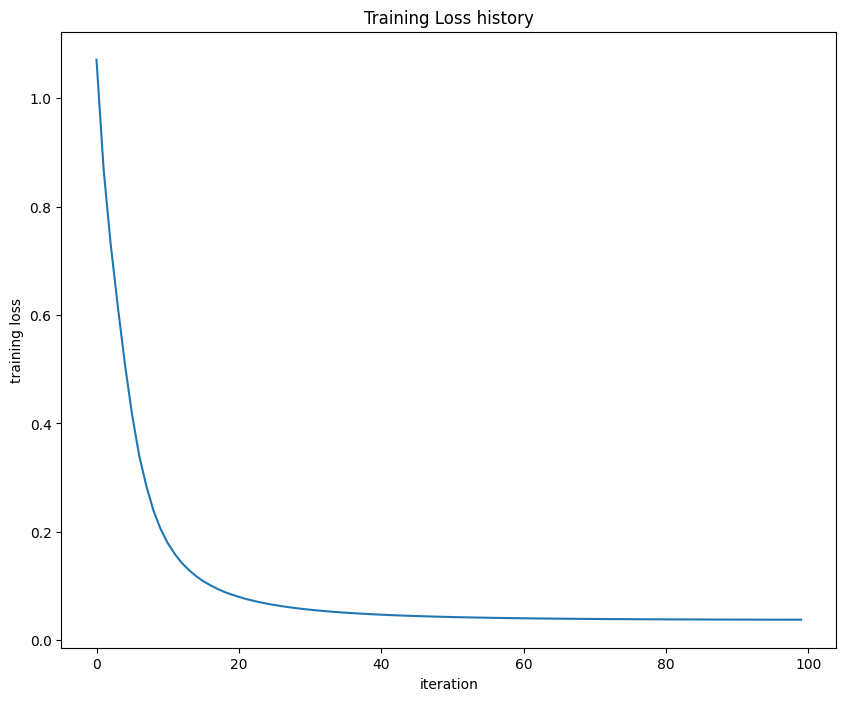

In [20]:
net = init_toy_model(input_size, hidden_size, num_classes, std)
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

final_train_loss = stats['loss_history'][-1]
print('Final training loss: ', final_train_loss)
assert final_train_loss < 0.2, (
    f'Task 4.4 failed: final training loss too high ({final_train_loss:.6f} >= 0.2)'
)
print(f'Task 4.4 passed: final training loss is small ({final_train_loss:.6f}).')

# plot the loss history
plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()


# Load the data
Now that you have implemented a two-layer network that passes gradient checks and works on toy data, it's time to load up our favorite CIFAR-10 data so we can use it to train a classifier on a real dataset.

In [22]:
from data_utils import load_CIFAR10

def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):

    """
    Load the CIFAR-10 dataset from disk and perform preprocessing to prepare
    it for the two-layer neural net classifier. These are the same steps as
    we used for the SVM, but condensed to a single function.  
    """

    # Load the raw CIFAR-10 data
    cifar10_dir = 'datasets/cifar-10-batches-py/'
    X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_CIFAR10(cifar10_dir)
        
    # convert to Torch Tensors
    X_train_raw = torch.from_numpy(X_train_raw).float()
    y_train_raw = torch.from_numpy(y_train_raw).long()
    X_test_raw = torch.from_numpy(X_test_raw).float()
    y_test_raw = torch.from_numpy(y_test_raw).long()

    # Subsample the data
    mask_val = slice(num_training, num_training + num_validation)
    X_val = X_train_raw[mask_val]
    y_val = y_train_raw[mask_val]
    
    # Training
    mask_train = slice(0, num_training)
    X_train = X_train_raw[mask_train]
    y_train = y_train_raw[mask_train]
    
    # Test
    mask_test = slice(0, num_test)
    X_test = X_test_raw[mask_test]
    y_test = y_test_raw[mask_test]

    # Normalize the data: subtract the mean image
    mean_image = torch.mean(X_train, dim=0)
    X_train -= mean_image
    X_val -= mean_image
    X_test -= mean_image

    # Reshape data to rows
    X_train = X_train.reshape(num_training, -1)
    X_val = X_val.reshape(num_validation, -1)
    X_test = X_test.reshape(num_test, -1)

    return X_train, y_train, X_val, y_val, X_test, y_test

# Invoke the above function to get our data.
X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()

X_train = X_train.double()
X_val = X_val.double()
X_test = X_test.double()

print(f'Train data shape: {X_train.shape}')
print(f'Train labels shape: {y_train.shape}')
print(f'Validation data shape: {X_val.shape}')
print(f'Validation labels shape: {y_val.shape}')
print(f'Test data shape: {X_test.shape}')
print(f'Test labels shape: {y_test.shape}')

d:\Artem\Tartu_CS\1st year\Neural Nets\HW4\data_utils.py:14: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return  pickle.load(f, encoding='latin1')


Train data shape: torch.Size([49000, 3072])
Train labels shape: torch.Size([49000])
Validation data shape: torch.Size([1000, 3072])
Validation labels shape: torch.Size([1000])
Test data shape: torch.Size([1000, 3072])
Test labels shape: torch.Size([1000])


# Train a network
To train our network we will use SGD. In addition, we will adjust the learning rate with an exponential learning rate schedule as optimization proceeds; after each epoch, we will reduce the learning rate by multiplying it by a number smaller than one called "decay rate".

In [25]:
input_size = 32 * 32 * 3  
hidden_size = 50
num_classes = 10
std = 1e-3

net = init_toy_model(input_size, hidden_size, num_classes, std)

stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

# Predict on the validation set
val_predictions = net.predict(X_val)
val_acc = torch.mean((val_predictions == y_val).float()).item()
print('Validation accuracy: ', val_acc)

iteration 0 / 1000: loss 2.342349
iteration 100 / 1000: loss 2.300441
iteration 200 / 1000: loss 2.219120
iteration 300 / 1000: loss 2.165721
iteration 400 / 1000: loss 2.036960
iteration 500 / 1000: loss 2.011355
iteration 600 / 1000: loss 1.914130
iteration 700 / 1000: loss 2.019099
iteration 800 / 1000: loss 1.882130
iteration 900 / 1000: loss 1.962653
Validation accuracy:  0.35600000619888306


# Debug the training
With the default parameters we provided above, you should get a validation accuracy of about 0.29 on the validation set. This isn't very good.

One strategy for getting insight into what's wrong is to plot the loss function and the accuracies on the training and validation sets during optimization.

Another strategy is to visualize the weights that were learned in the first layer of the network. In most neural networks trained on visual data, the first layer weights typically show some visible structure when visualized.

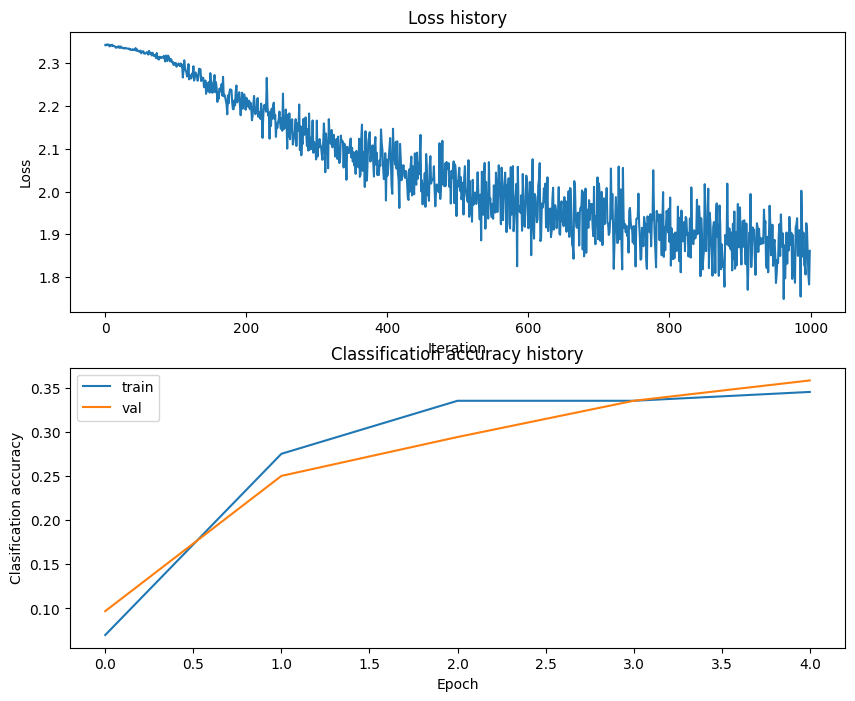

In [26]:
# Plot the loss function and train / validation accuracies
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Clasification accuracy')
plt.legend()
plt.show()

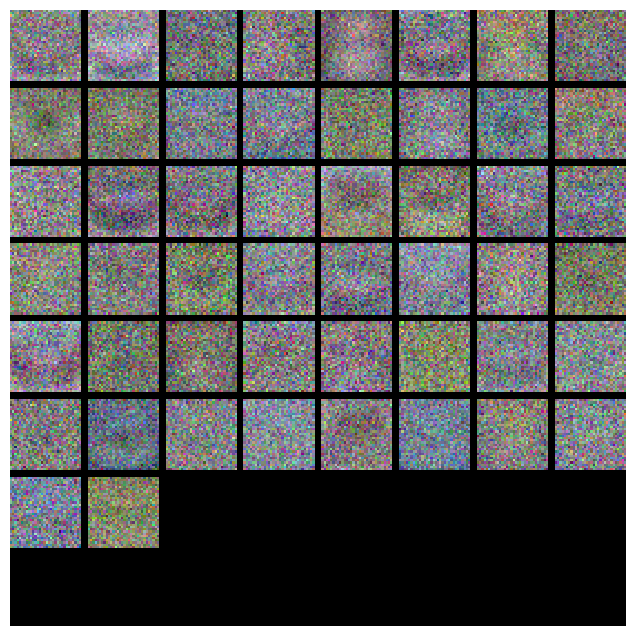

In [27]:
from vis_utils import visualize_grid

def show_net_weights(net):

    W1 = net.params['W1'].detach().cpu().numpy()
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    
    grid = visualize_grid(W1, padding=3).astype('uint8')
    plt.imshow(grid)
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

# Tune your hyperparameters

**What's wrong?**. Looking at the visualizations above, we see that the loss is decreasing more or less linearly, which seems to suggest that the learning rate may be too low. Moreover, there is no gap between the training and validation accuracy, suggesting that the model we used has low capacity, and that we should increase its size. On the other hand, with a very large model we would expect to see more overfitting, which would manifest itself as a very large gap between the training and validation accuracy.

**Tuning**. Tuning the hyperparameters and developing intuition for how they affect the final performance is a large part of using Neural Networks, so we want you to get a lot of practice. Below, you should experiment with different values of the various hyperparameters, including hidden layer size, learning rate, numer of training epochs, and regularization strength. You might also consider tuning the learning rate decay, but you should be able to get good performance using the default value.

**Approximate results**. You should be aim to achieve a classification accuracy of greater than 48% on the validation set. Our best network gets over 52% on the validation set.

### Task 4.5
**Experiment**: You goal in this exercise is to get as good of a result on CIFAR-10 as you can, with a fully-connected Neural Network. For every 1% above 52% on the Test set we will award you with one extra bonus point. Feel free implement your own techniques (e.g. PCA to reduce dimensionality, or adding dropout, or adding features to the solver, etc.).

In [43]:
import matplotlib.pyplot as plt
import numpy as np

def plot_train_val_loss(stats, iterations_per_epoch=None, train_every=None):
    train_loss = np.asarray(stats.get('loss_history', []), dtype=float)
    val_loss = np.asarray(stats.get('val_loss_history', []), dtype=float)

    # Pick a reasonable default sampling interval for train-loss markers.
    if train_every is None:
        if iterations_per_epoch is not None:
            train_every = int(iterations_per_epoch)
        elif len(train_loss) > 0 and len(val_loss) > 1:
            train_every = max(1, int(round((len(train_loss) - 1) / (len(val_loss) - 1))))
        else:
            train_every = max(1, len(train_loss) // 20) if len(train_loss) > 0 else 1

    plt.figure(figsize=(8, 5))

    # Train loss: show a faint full curve + sparse markers every `train_every` iterations.
    if len(train_loss) > 0:
        it_train = np.arange(len(train_loss))
        plt.plot(it_train, train_loss, alpha=0.25, linewidth=1, label='train loss (all)')

        idx = np.arange(0, len(train_loss), train_every, dtype=int)
        plt.plot(it_train[idx], train_loss[idx], marker='o', linewidth=1, label=f'train loss (every {train_every})')

    # Validation loss: plotted at epoch boundaries on the same iteration axis.
    if len(val_loss) > 0:
        if iterations_per_epoch is None:
            # Validation loss is logged once per epoch (including at iter=0).
            # When we don't know iterations_per_epoch, infer x-positions so val points
            # span the same iteration axis as train_loss.
            if len(train_loss) > 0 and len(val_loss) > 1:
                x_val = np.linspace(0, len(train_loss) - 1, num=len(val_loss))
            else:
                x_val = np.arange(len(val_loss))
        else:
            x_val = np.arange(len(val_loss)) * iterations_per_epoch

        plt.plot(x_val, val_loss, label='val loss', marker='o', linewidth=1)

    plt.xlabel('iteration')
    plt.ylabel('loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [42]:
task45_model_cache = globals().get('task45_model_cache', {})
task45_sweep_history = globals().get('task45_sweep_history', [])
globals()['task45_model_cache'] = task45_model_cache
globals()['task45_sweep_history'] = task45_sweep_history

def task45_cache_key(lr, reg, hidden_size, batch_size, std, num_iters, learning_rate_decay):
    return (lr, reg, hidden_size, batch_size, std, num_iters, learning_rate_decay)

def task45_show_summary(results, title='Task 4.5 sweep summary'):
    ordered = sorted(results, key=lambda x: x['val_acc'], reverse=True)
    top = ordered[:min(12, len(ordered))]
    labels = [
        f"lr={r['params']['lr']:.0e}\nreg={r['params']['reg']:.2f}, h={r['params']['hidden_size']}, b={r['params']['batch_size']}"
        for r in top
    ]
    values = [r['val_acc'] for r in top]

    plt.figure(figsize=(10, max(4, 0.55 * len(top))))
    plt.barh(range(len(top)), values)
    plt.yticks(range(len(top)), labels)
    plt.gca().invert_yaxis()
    plt.xlabel('validation accuracy')
    plt.title(title)
    plt.grid(axis='x', alpha=0.3)
    plt.show()

    for idx, r in enumerate(ordered[:min(10, len(ordered))], start=1):
        p = r['params']
        print(
            f"{idx:02d}. val_acc={r['val_acc']:.4f} | "
            f"lr={p['lr']:.1e}, reg={p['reg']:.2f}, hidden={p['hidden_size']}, batch={p['batch_size']}"
        )

lr: 0.0003, reg: 0.1, hidden_size: 200, batch_size: 100
Validation accuracy:  0.5009999871253967
lr: 3.0e-04, reg: 0.10, hidden: 200, batch: 100, val_acc: 0.5010


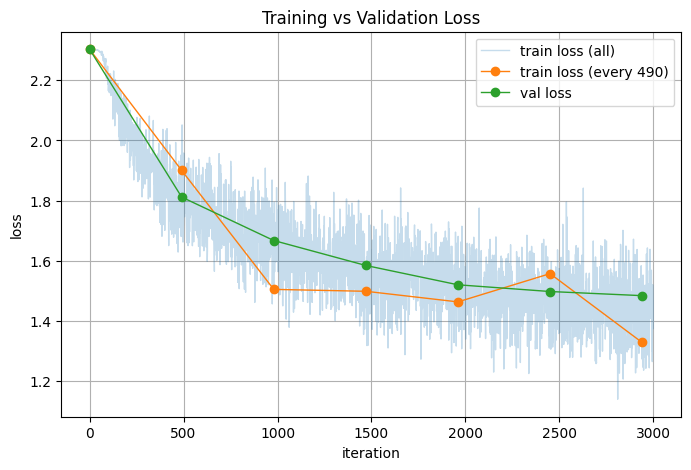

lr: 0.0003, reg: 0.1, hidden_size: 200, batch_size: 200
iteration 0 / 3000: loss 2.303194
iteration 100 / 3000: loss 2.214380
iteration 200 / 3000: loss 2.060307
iteration 300 / 3000: loss 1.982565
iteration 400 / 3000: loss 1.774952
iteration 500 / 3000: loss 1.780104
iteration 600 / 3000: loss 1.772944
iteration 700 / 3000: loss 1.664132
iteration 800 / 3000: loss 1.789693
iteration 900 / 3000: loss 1.656880
iteration 1000 / 3000: loss 1.595853
iteration 1100 / 3000: loss 1.621105
iteration 1200 / 3000: loss 1.580537
iteration 1300 / 3000: loss 1.596163
iteration 1400 / 3000: loss 1.579180
iteration 1500 / 3000: loss 1.631392
iteration 1600 / 3000: loss 1.507522
iteration 1700 / 3000: loss 1.560076
iteration 1800 / 3000: loss 1.601845
iteration 1900 / 3000: loss 1.416285
iteration 2000 / 3000: loss 1.536129
iteration 2100 / 3000: loss 1.431933
iteration 2200 / 3000: loss 1.470018
iteration 2300 / 3000: loss 1.587782
iteration 2400 / 3000: loss 1.432093
iteration 2500 / 3000: loss 1.3

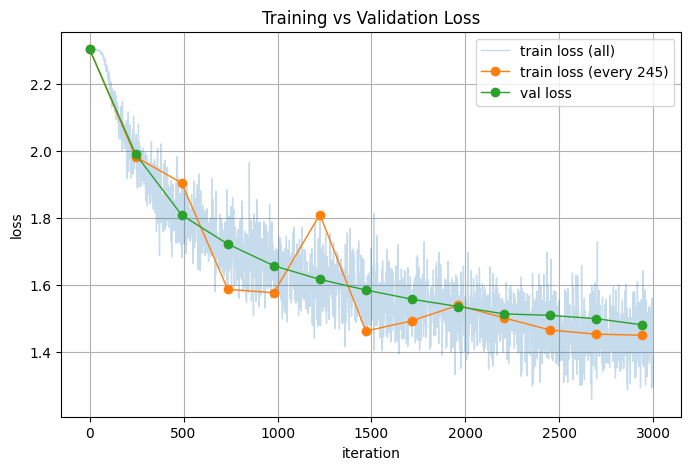

lr: 0.0003, reg: 0.1, hidden_size: 200, batch_size: 400
iteration 0 / 3000: loss 2.303224
iteration 100 / 3000: loss 2.223247
iteration 200 / 3000: loss 2.061910
iteration 300 / 3000: loss 1.939629
iteration 400 / 3000: loss 1.850534
iteration 500 / 3000: loss 1.802114
iteration 600 / 3000: loss 1.768631
iteration 700 / 3000: loss 1.720389
iteration 800 / 3000: loss 1.634140
iteration 900 / 3000: loss 1.743665
iteration 1000 / 3000: loss 1.659591
iteration 1100 / 3000: loss 1.676418
iteration 1200 / 3000: loss 1.590604
iteration 1300 / 3000: loss 1.612809
iteration 1400 / 3000: loss 1.477140
iteration 1500 / 3000: loss 1.583194
iteration 1600 / 3000: loss 1.553300
iteration 1700 / 3000: loss 1.580162
iteration 1800 / 3000: loss 1.530824
iteration 1900 / 3000: loss 1.530283
iteration 2000 / 3000: loss 1.564391
iteration 2100 / 3000: loss 1.540332
iteration 2200 / 3000: loss 1.494651
iteration 2300 / 3000: loss 1.492914
iteration 2400 / 3000: loss 1.523353
iteration 2500 / 3000: loss 1.4

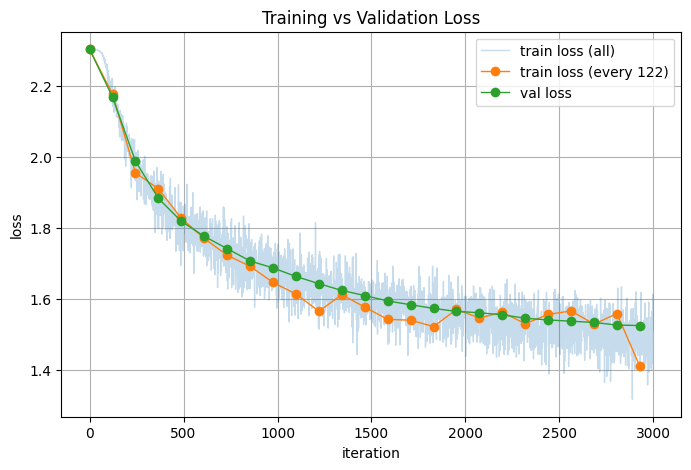

lr: 0.0003, reg: 0.1, hidden_size: 300, batch_size: 100
iteration 0 / 3000: loss 2.303508
iteration 100 / 3000: loss 2.191194
iteration 200 / 3000: loss 2.074825
iteration 300 / 3000: loss 1.896004
iteration 400 / 3000: loss 1.990829
iteration 500 / 3000: loss 1.827042
iteration 600 / 3000: loss 1.733019
iteration 700 / 3000: loss 1.697219
iteration 800 / 3000: loss 1.705397
iteration 900 / 3000: loss 1.845340
iteration 1000 / 3000: loss 1.670836
iteration 1100 / 3000: loss 1.560238
iteration 1200 / 3000: loss 1.513295
iteration 1300 / 3000: loss 1.649878
iteration 1400 / 3000: loss 1.572202
iteration 1500 / 3000: loss 1.555376
iteration 1600 / 3000: loss 1.564113
iteration 1700 / 3000: loss 1.617947
iteration 1800 / 3000: loss 1.432480
iteration 1900 / 3000: loss 1.501238
iteration 2000 / 3000: loss 1.304485
iteration 2100 / 3000: loss 1.473272
iteration 2200 / 3000: loss 1.686019
iteration 2300 / 3000: loss 1.466839
iteration 2400 / 3000: loss 1.576202
iteration 2500 / 3000: loss 1.4

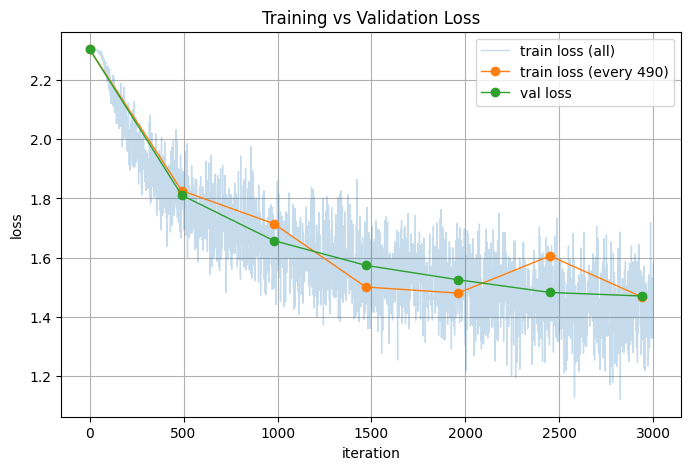

lr: 0.0003, reg: 0.1, hidden_size: 300, batch_size: 200
iteration 0 / 3000: loss 2.303508
iteration 100 / 3000: loss 2.209500
iteration 200 / 3000: loss 2.069285
iteration 300 / 3000: loss 1.970282
iteration 400 / 3000: loss 1.849415
iteration 500 / 3000: loss 1.841498
iteration 600 / 3000: loss 1.766831
iteration 700 / 3000: loss 1.685990
iteration 800 / 3000: loss 1.708919
iteration 900 / 3000: loss 1.639375
iteration 1000 / 3000: loss 1.753408
iteration 1100 / 3000: loss 1.682792
iteration 1200 / 3000: loss 1.620503
iteration 1300 / 3000: loss 1.579612
iteration 1400 / 3000: loss 1.389848
iteration 1500 / 3000: loss 1.569016
iteration 1600 / 3000: loss 1.497958
iteration 1700 / 3000: loss 1.539970
iteration 1800 / 3000: loss 1.518897
iteration 1900 / 3000: loss 1.473409
iteration 2000 / 3000: loss 1.495848
iteration 2100 / 3000: loss 1.503603
iteration 2200 / 3000: loss 1.468422
iteration 2300 / 3000: loss 1.537729
iteration 2400 / 3000: loss 1.439530
iteration 2500 / 3000: loss 1.5

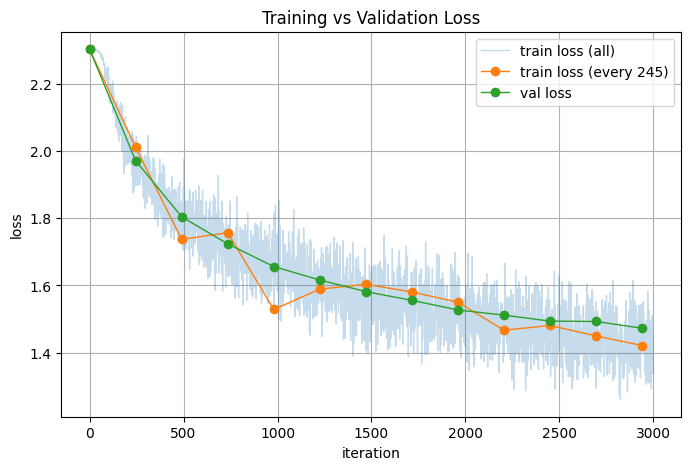

lr: 0.0003, reg: 0.1, hidden_size: 300, batch_size: 400
iteration 0 / 3000: loss 2.303438
iteration 100 / 3000: loss 2.196545
iteration 200 / 3000: loss 2.033960
iteration 300 / 3000: loss 1.920102
iteration 400 / 3000: loss 1.899617
iteration 500 / 3000: loss 1.775631
iteration 600 / 3000: loss 1.739585
iteration 700 / 3000: loss 1.713693
iteration 800 / 3000: loss 1.730063
iteration 900 / 3000: loss 1.672320
iteration 1000 / 3000: loss 1.665756
iteration 1100 / 3000: loss 1.622297
iteration 1200 / 3000: loss 1.587540
iteration 1300 / 3000: loss 1.573372
iteration 1400 / 3000: loss 1.646774
iteration 1500 / 3000: loss 1.577170
iteration 1600 / 3000: loss 1.615446
iteration 1700 / 3000: loss 1.643151
iteration 1800 / 3000: loss 1.560755
iteration 1900 / 3000: loss 1.576875
iteration 2000 / 3000: loss 1.491200
iteration 2100 / 3000: loss 1.557378
iteration 2200 / 3000: loss 1.567769
iteration 2300 / 3000: loss 1.472174
iteration 2400 / 3000: loss 1.548546
iteration 2500 / 3000: loss 1.5

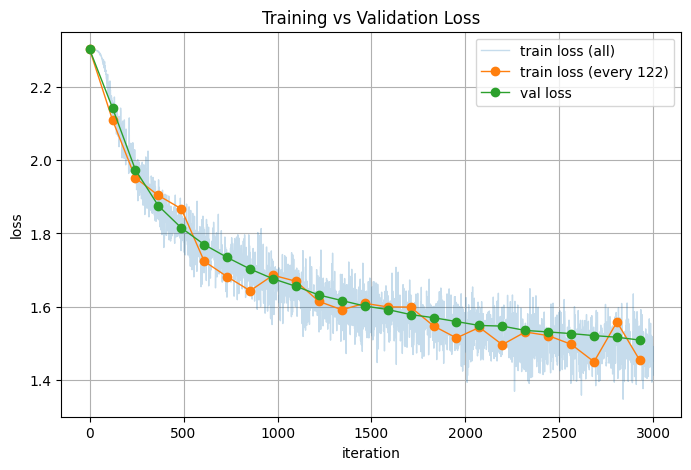

lr: 0.0003, reg: 0.1, hidden_size: 400, batch_size: 100
iteration 0 / 3000: loss 2.303739
iteration 100 / 3000: loss 2.191359
iteration 200 / 3000: loss 2.166020
iteration 300 / 3000: loss 1.968224
iteration 400 / 3000: loss 1.908171
iteration 500 / 3000: loss 1.775112
iteration 600 / 3000: loss 1.716442
iteration 700 / 3000: loss 1.586762
iteration 800 / 3000: loss 1.655832
iteration 900 / 3000: loss 1.754538
iteration 1000 / 3000: loss 1.604970
iteration 1100 / 3000: loss 1.563853
iteration 1200 / 3000: loss 1.560891
iteration 1300 / 3000: loss 1.489176
iteration 1400 / 3000: loss 1.655724
iteration 1500 / 3000: loss 1.783120
iteration 1600 / 3000: loss 1.441190
iteration 1700 / 3000: loss 1.482116
iteration 1800 / 3000: loss 1.467069
iteration 1900 / 3000: loss 1.467590
iteration 2000 / 3000: loss 1.461248
iteration 2100 / 3000: loss 1.507009
iteration 2200 / 3000: loss 1.548755
iteration 2300 / 3000: loss 1.527862
iteration 2400 / 3000: loss 1.379630
iteration 2500 / 3000: loss 1.4

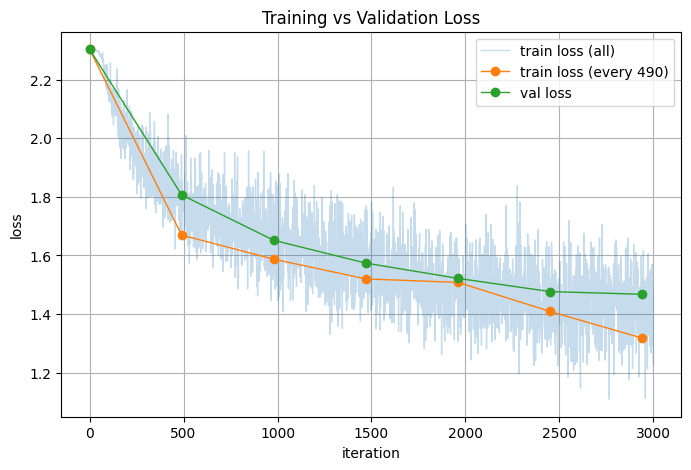

lr: 0.0003, reg: 0.1, hidden_size: 400, batch_size: 200
iteration 0 / 3000: loss 2.303846
iteration 100 / 3000: loss 2.207293
iteration 200 / 3000: loss 2.027381
iteration 300 / 3000: loss 1.895738
iteration 400 / 3000: loss 1.829213
iteration 500 / 3000: loss 1.833306
iteration 600 / 3000: loss 1.814440
iteration 700 / 3000: loss 1.633510
iteration 800 / 3000: loss 1.724261
iteration 900 / 3000: loss 1.683605
iteration 1000 / 3000: loss 1.701301
iteration 1100 / 3000: loss 1.526565
iteration 1200 / 3000: loss 1.600066
iteration 1300 / 3000: loss 1.612323
iteration 1400 / 3000: loss 1.531064
iteration 1500 / 3000: loss 1.524757
iteration 1600 / 3000: loss 1.562987
iteration 1700 / 3000: loss 1.485330
iteration 1800 / 3000: loss 1.556728
iteration 1900 / 3000: loss 1.452592
iteration 2000 / 3000: loss 1.593598
iteration 2100 / 3000: loss 1.491195
iteration 2200 / 3000: loss 1.429496
iteration 2300 / 3000: loss 1.371773
iteration 2400 / 3000: loss 1.348310
iteration 2500 / 3000: loss 1.5

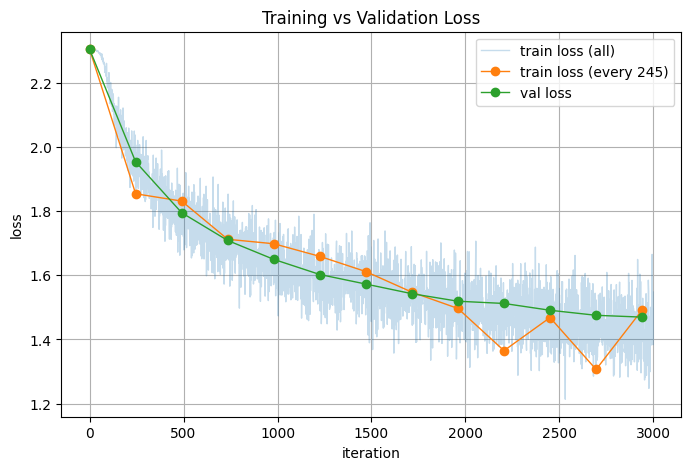

lr: 0.0003, reg: 0.1, hidden_size: 400, batch_size: 400
iteration 0 / 3000: loss 2.303834
iteration 100 / 3000: loss 2.203156
iteration 200 / 3000: loss 2.040294
iteration 300 / 3000: loss 1.955244
iteration 400 / 3000: loss 1.861395
iteration 500 / 3000: loss 1.853389
iteration 600 / 3000: loss 1.719864
iteration 700 / 3000: loss 1.779770
iteration 800 / 3000: loss 1.656161
iteration 900 / 3000: loss 1.605985
iteration 1000 / 3000: loss 1.709357
iteration 1100 / 3000: loss 1.649034
iteration 1200 / 3000: loss 1.473389
iteration 1300 / 3000: loss 1.589853
iteration 1400 / 3000: loss 1.582166
iteration 1500 / 3000: loss 1.511634
iteration 1600 / 3000: loss 1.551949
iteration 1700 / 3000: loss 1.524501
iteration 1800 / 3000: loss 1.586866
iteration 1900 / 3000: loss 1.515121
iteration 2000 / 3000: loss 1.570686
iteration 2100 / 3000: loss 1.572480
iteration 2200 / 3000: loss 1.442510
iteration 2300 / 3000: loss 1.470325
iteration 2400 / 3000: loss 1.555221
iteration 2500 / 3000: loss 1.5

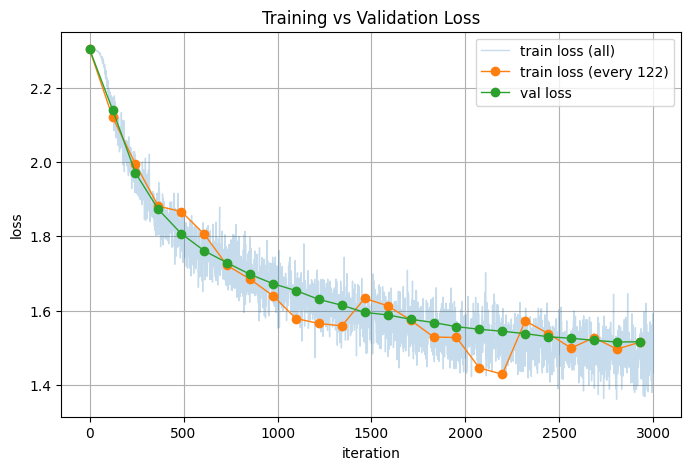

lr: 0.0003, reg: 0.1, hidden_size: 500, batch_size: 100
iteration 0 / 3000: loss 2.304052
iteration 100 / 3000: loss 2.168151
iteration 200 / 3000: loss 1.928933
iteration 300 / 3000: loss 1.902804
iteration 400 / 3000: loss 1.999061
iteration 500 / 3000: loss 1.867168
iteration 600 / 3000: loss 1.597529
iteration 700 / 3000: loss 1.773582
iteration 800 / 3000: loss 1.652017
iteration 900 / 3000: loss 1.621671
iteration 1000 / 3000: loss 1.550252
iteration 1100 / 3000: loss 1.672539
iteration 1200 / 3000: loss 1.563692
iteration 1300 / 3000: loss 1.643184
iteration 1400 / 3000: loss 1.426115
iteration 1500 / 3000: loss 1.599837
iteration 1600 / 3000: loss 1.704883
iteration 1700 / 3000: loss 1.518101
iteration 1800 / 3000: loss 1.363913
iteration 1900 / 3000: loss 1.335102
iteration 2000 / 3000: loss 1.463452
iteration 2100 / 3000: loss 1.523640
iteration 2200 / 3000: loss 1.479770
iteration 2300 / 3000: loss 1.450724
iteration 2400 / 3000: loss 1.258064
iteration 2500 / 3000: loss 1.3

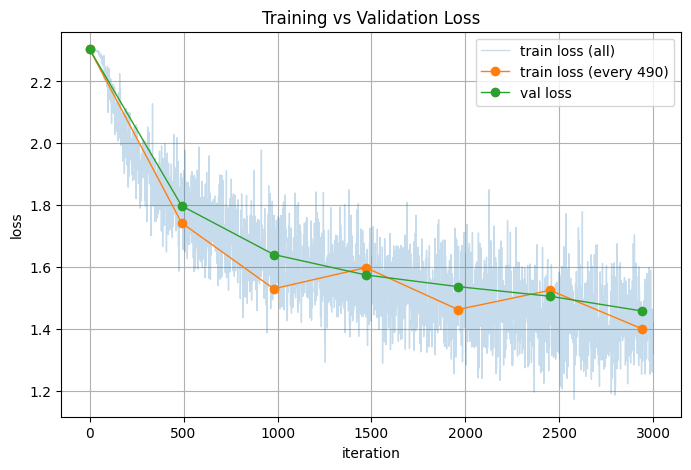

lr: 0.0003, reg: 0.1, hidden_size: 500, batch_size: 200
iteration 0 / 3000: loss 2.304124
iteration 100 / 3000: loss 2.187095
iteration 200 / 3000: loss 1.966783
iteration 300 / 3000: loss 1.933978
iteration 400 / 3000: loss 1.682602
iteration 500 / 3000: loss 1.775947
iteration 600 / 3000: loss 1.788182
iteration 700 / 3000: loss 1.694184
iteration 800 / 3000: loss 1.655300
iteration 900 / 3000: loss 1.508425
iteration 1000 / 3000: loss 1.608769
iteration 1100 / 3000: loss 1.622442
iteration 1200 / 3000: loss 1.571854
iteration 1300 / 3000: loss 1.660560
iteration 1400 / 3000: loss 1.602375
iteration 1500 / 3000: loss 1.562220
iteration 1600 / 3000: loss 1.568109
iteration 1700 / 3000: loss 1.431545
iteration 1800 / 3000: loss 1.571131
iteration 1900 / 3000: loss 1.558208
iteration 2000 / 3000: loss 1.351341
iteration 2100 / 3000: loss 1.477800
iteration 2200 / 3000: loss 1.485220
iteration 2300 / 3000: loss 1.466136
iteration 2400 / 3000: loss 1.454967
iteration 2500 / 3000: loss 1.4

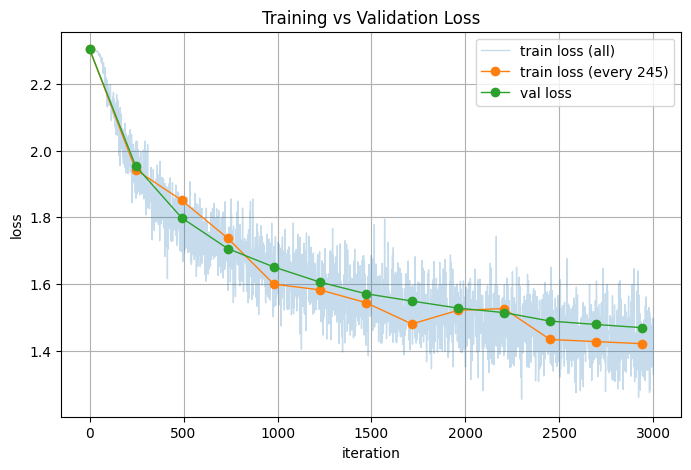

lr: 0.0003, reg: 0.1, hidden_size: 500, batch_size: 400
iteration 0 / 3000: loss 2.304126
iteration 100 / 3000: loss 2.183274
iteration 200 / 3000: loss 2.036094
iteration 300 / 3000: loss 1.960804
iteration 400 / 3000: loss 1.837553
iteration 500 / 3000: loss 1.918845
iteration 600 / 3000: loss 1.711488
iteration 700 / 3000: loss 1.714836
iteration 800 / 3000: loss 1.663497
iteration 900 / 3000: loss 1.723854
iteration 1000 / 3000: loss 1.605446
iteration 1100 / 3000: loss 1.615260
iteration 1200 / 3000: loss 1.605988
iteration 1300 / 3000: loss 1.555837
iteration 1400 / 3000: loss 1.669790
iteration 1500 / 3000: loss 1.617014
iteration 1600 / 3000: loss 1.565379
iteration 1700 / 3000: loss 1.503566
iteration 1800 / 3000: loss 1.638093
iteration 1900 / 3000: loss 1.604739
iteration 2000 / 3000: loss 1.460239
iteration 2100 / 3000: loss 1.463080
iteration 2200 / 3000: loss 1.564614
iteration 2300 / 3000: loss 1.499258
iteration 2400 / 3000: loss 1.539713
iteration 2500 / 3000: loss 1.4

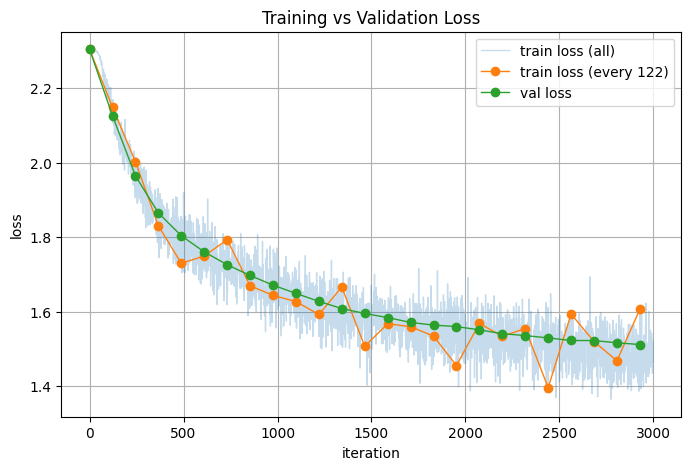

lr: 0.0003, reg: 0.25, hidden_size: 200, batch_size: 100
iteration 0 / 3000: loss 2.304150
iteration 100 / 3000: loss 2.195180
iteration 200 / 3000: loss 2.075293
iteration 300 / 3000: loss 1.878430
iteration 400 / 3000: loss 1.810291
iteration 500 / 3000: loss 1.685707
iteration 600 / 3000: loss 1.729827
iteration 700 / 3000: loss 1.842792
iteration 800 / 3000: loss 1.667521
iteration 900 / 3000: loss 1.632442
iteration 1000 / 3000: loss 1.700111
iteration 1100 / 3000: loss 1.558841
iteration 1200 / 3000: loss 1.715760
iteration 1300 / 3000: loss 1.802620
iteration 1400 / 3000: loss 1.577300
iteration 1500 / 3000: loss 1.554282
iteration 1600 / 3000: loss 1.800156
iteration 1700 / 3000: loss 1.726110
iteration 1800 / 3000: loss 1.507679
iteration 1900 / 3000: loss 1.566303
iteration 2000 / 3000: loss 1.295512
iteration 2100 / 3000: loss 1.531023
iteration 2200 / 3000: loss 1.555813
iteration 2300 / 3000: loss 1.476951
iteration 2400 / 3000: loss 1.437292
iteration 2500 / 3000: loss 1.

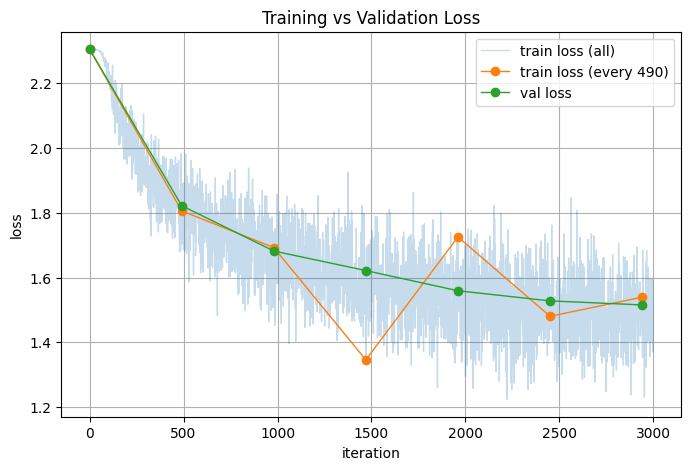

lr: 0.0003, reg: 0.25, hidden_size: 200, batch_size: 200
iteration 0 / 3000: loss 2.304132
iteration 100 / 3000: loss 2.214098
iteration 200 / 3000: loss 2.094357
iteration 300 / 3000: loss 1.860516
iteration 400 / 3000: loss 1.855082
iteration 500 / 3000: loss 1.912008
iteration 600 / 3000: loss 1.817022
iteration 700 / 3000: loss 1.780905
iteration 800 / 3000: loss 1.704467
iteration 900 / 3000: loss 1.646786
iteration 1000 / 3000: loss 1.568886
iteration 1100 / 3000: loss 1.643220
iteration 1200 / 3000: loss 1.663563
iteration 1300 / 3000: loss 1.734761
iteration 1400 / 3000: loss 1.771187
iteration 1500 / 3000: loss 1.529295
iteration 1600 / 3000: loss 1.560957
iteration 1700 / 3000: loss 1.626035
iteration 1800 / 3000: loss 1.636160
iteration 1900 / 3000: loss 1.718159
iteration 2000 / 3000: loss 1.659323
iteration 2100 / 3000: loss 1.660923
iteration 2200 / 3000: loss 1.436223
iteration 2300 / 3000: loss 1.496723
iteration 2400 / 3000: loss 1.510386
iteration 2500 / 3000: loss 1.

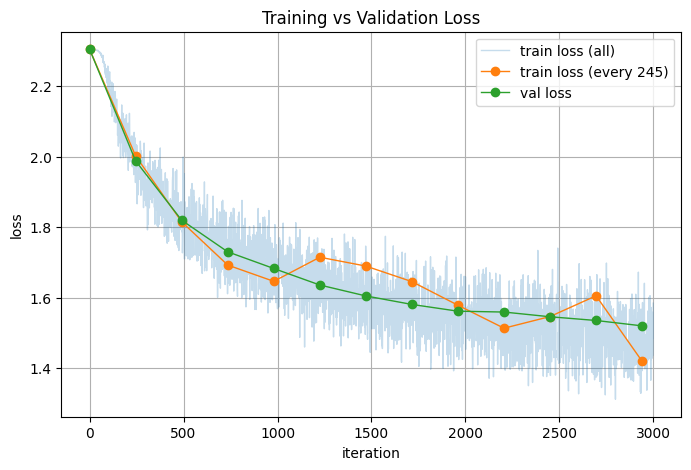

lr: 0.0003, reg: 0.25, hidden_size: 200, batch_size: 400
iteration 0 / 3000: loss 2.304130
iteration 100 / 3000: loss 2.227491
iteration 200 / 3000: loss 2.027240
iteration 300 / 3000: loss 1.961636
iteration 400 / 3000: loss 1.911290
iteration 500 / 3000: loss 1.799479
iteration 600 / 3000: loss 1.729526
iteration 700 / 3000: loss 1.754900
iteration 800 / 3000: loss 1.659991
iteration 900 / 3000: loss 1.706152
iteration 1000 / 3000: loss 1.640935
iteration 1100 / 3000: loss 1.677292
iteration 1200 / 3000: loss 1.608032
iteration 1300 / 3000: loss 1.668457
iteration 1400 / 3000: loss 1.603467
iteration 1500 / 3000: loss 1.613392
iteration 1600 / 3000: loss 1.698727
iteration 1700 / 3000: loss 1.544219
iteration 1800 / 3000: loss 1.577113
iteration 1900 / 3000: loss 1.587259
iteration 2000 / 3000: loss 1.601379
iteration 2100 / 3000: loss 1.532509
iteration 2200 / 3000: loss 1.583945
iteration 2300 / 3000: loss 1.496846
iteration 2400 / 3000: loss 1.564339
iteration 2500 / 3000: loss 1.

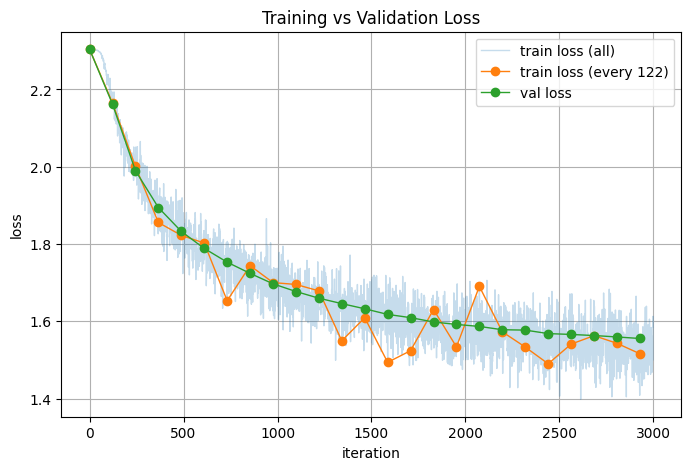

lr: 0.0003, reg: 0.25, hidden_size: 300, batch_size: 100
iteration 0 / 3000: loss 2.304983
iteration 100 / 3000: loss 2.228810
iteration 200 / 3000: loss 2.078233
iteration 300 / 3000: loss 1.862611
iteration 400 / 3000: loss 1.766111
iteration 500 / 3000: loss 1.917265
iteration 600 / 3000: loss 1.702436
iteration 700 / 3000: loss 1.918988
iteration 800 / 3000: loss 1.666530
iteration 900 / 3000: loss 1.762936
iteration 1000 / 3000: loss 1.711852
iteration 1100 / 3000: loss 1.752741
iteration 1200 / 3000: loss 1.736269
iteration 1300 / 3000: loss 1.526483
iteration 1400 / 3000: loss 1.553975
iteration 1500 / 3000: loss 1.501088
iteration 1600 / 3000: loss 1.523796
iteration 1700 / 3000: loss 1.538190
iteration 1800 / 3000: loss 1.524329
iteration 1900 / 3000: loss 1.545324
iteration 2000 / 3000: loss 1.569102
iteration 2100 / 3000: loss 1.516303
iteration 2200 / 3000: loss 1.423956
iteration 2300 / 3000: loss 1.507344
iteration 2400 / 3000: loss 1.469932
iteration 2500 / 3000: loss 1.

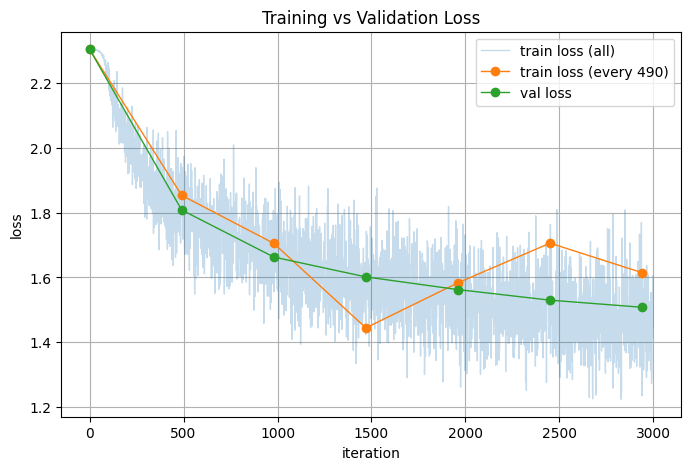

lr: 0.0003, reg: 0.25, hidden_size: 300, batch_size: 200
iteration 0 / 3000: loss 2.304857
iteration 100 / 3000: loss 2.157112
iteration 200 / 3000: loss 1.989022
iteration 300 / 3000: loss 1.796415
iteration 400 / 3000: loss 1.914191
iteration 500 / 3000: loss 1.817538
iteration 600 / 3000: loss 1.752948
iteration 700 / 3000: loss 1.672632
iteration 800 / 3000: loss 1.745332
iteration 900 / 3000: loss 1.793482
iteration 1000 / 3000: loss 1.725417
iteration 1100 / 3000: loss 1.612078
iteration 1200 / 3000: loss 1.566446
iteration 1300 / 3000: loss 1.613562
iteration 1400 / 3000: loss 1.487977
iteration 1500 / 3000: loss 1.593250
iteration 1600 / 3000: loss 1.636650
iteration 1700 / 3000: loss 1.617224
iteration 1800 / 3000: loss 1.570103
iteration 1900 / 3000: loss 1.387495
iteration 2000 / 3000: loss 1.463040
iteration 2100 / 3000: loss 1.570504
iteration 2200 / 3000: loss 1.374574
iteration 2300 / 3000: loss 1.527133
iteration 2400 / 3000: loss 1.403391
iteration 2500 / 3000: loss 1.

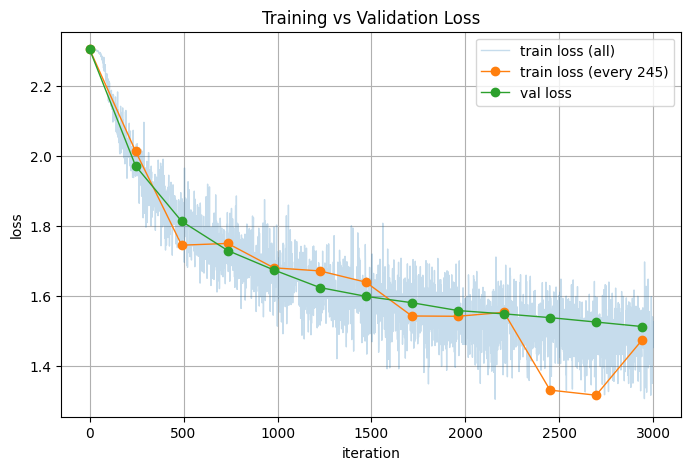

lr: 0.0003, reg: 0.25, hidden_size: 300, batch_size: 400
iteration 0 / 3000: loss 2.304874
iteration 100 / 3000: loss 2.175121
iteration 200 / 3000: loss 2.031462
iteration 300 / 3000: loss 1.902541
iteration 400 / 3000: loss 1.826113
iteration 500 / 3000: loss 1.848992
iteration 600 / 3000: loss 1.840792
iteration 700 / 3000: loss 1.762602
iteration 800 / 3000: loss 1.733412
iteration 900 / 3000: loss 1.652572
iteration 1000 / 3000: loss 1.747750
iteration 1100 / 3000: loss 1.631188
iteration 1200 / 3000: loss 1.729954
iteration 1300 / 3000: loss 1.666940
iteration 1400 / 3000: loss 1.659661
iteration 1500 / 3000: loss 1.581705
iteration 1600 / 3000: loss 1.657443
iteration 1700 / 3000: loss 1.605076
iteration 1800 / 3000: loss 1.565333
iteration 1900 / 3000: loss 1.635755
iteration 2000 / 3000: loss 1.561443
iteration 2100 / 3000: loss 1.538301
iteration 2200 / 3000: loss 1.618118
iteration 2300 / 3000: loss 1.545766
iteration 2400 / 3000: loss 1.505556
iteration 2500 / 3000: loss 1.

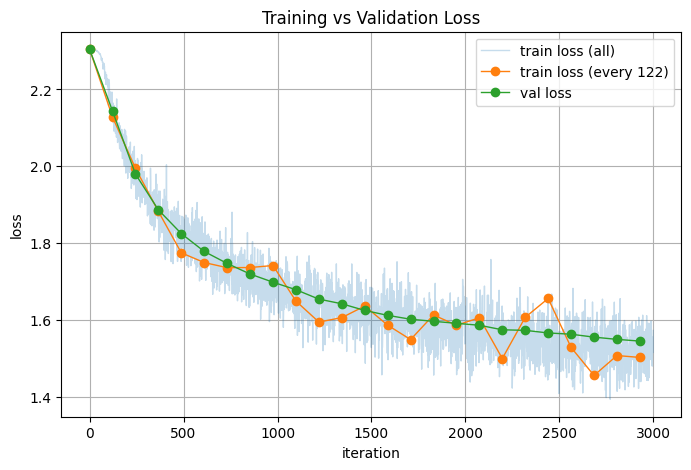

lr: 0.0003, reg: 0.25, hidden_size: 400, batch_size: 100
iteration 0 / 3000: loss 2.305691
iteration 100 / 3000: loss 2.187019
iteration 200 / 3000: loss 2.072057
iteration 300 / 3000: loss 1.880072
iteration 400 / 3000: loss 1.914631
iteration 500 / 3000: loss 1.721809
iteration 600 / 3000: loss 1.730282
iteration 700 / 3000: loss 1.757475
iteration 800 / 3000: loss 1.631625
iteration 900 / 3000: loss 1.521260
iteration 1000 / 3000: loss 1.630105
iteration 1100 / 3000: loss 1.502635
iteration 1200 / 3000: loss 1.502767
iteration 1300 / 3000: loss 1.805209
iteration 1400 / 3000: loss 1.606006
iteration 1500 / 3000: loss 1.594526
iteration 1600 / 3000: loss 1.627216
iteration 1700 / 3000: loss 1.448327
iteration 1800 / 3000: loss 1.499842
iteration 1900 / 3000: loss 1.435114
iteration 2000 / 3000: loss 1.449717
iteration 2100 / 3000: loss 1.478824
iteration 2200 / 3000: loss 1.447419
iteration 2300 / 3000: loss 1.480401
iteration 2400 / 3000: loss 1.549960
iteration 2500 / 3000: loss 1.

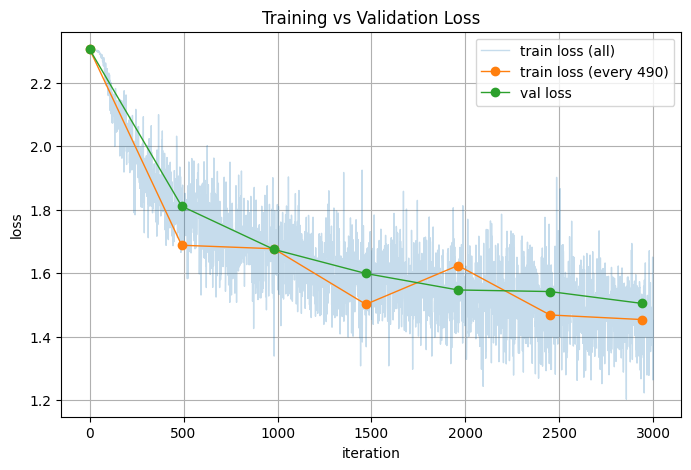

lr: 0.0003, reg: 0.25, hidden_size: 400, batch_size: 200
iteration 0 / 3000: loss 2.305676
iteration 100 / 3000: loss 2.237648
iteration 200 / 3000: loss 2.020420
iteration 300 / 3000: loss 1.904955
iteration 400 / 3000: loss 1.825111
iteration 500 / 3000: loss 1.789654
iteration 600 / 3000: loss 1.883914
iteration 700 / 3000: loss 1.637575
iteration 800 / 3000: loss 1.578123
iteration 900 / 3000: loss 1.688055
iteration 1000 / 3000: loss 1.686517
iteration 1100 / 3000: loss 1.676920
iteration 1200 / 3000: loss 1.675319
iteration 1300 / 3000: loss 1.645466
iteration 1400 / 3000: loss 1.619252
iteration 1500 / 3000: loss 1.729003
iteration 1600 / 3000: loss 1.581363
iteration 1700 / 3000: loss 1.495938
iteration 1800 / 3000: loss 1.599321
iteration 1900 / 3000: loss 1.560003
iteration 2000 / 3000: loss 1.490085
iteration 2100 / 3000: loss 1.484934
iteration 2200 / 3000: loss 1.387446
iteration 2300 / 3000: loss 1.581500
iteration 2400 / 3000: loss 1.530799
iteration 2500 / 3000: loss 1.

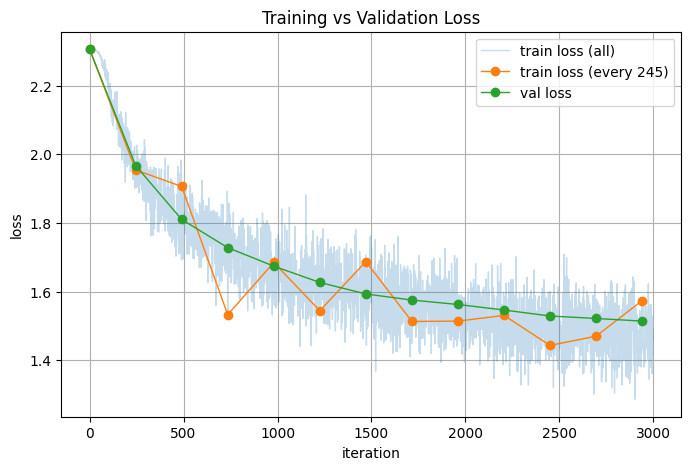

lr: 0.0003, reg: 0.25, hidden_size: 400, batch_size: 400
iteration 0 / 3000: loss 2.305599
iteration 100 / 3000: loss 2.167863
iteration 200 / 3000: loss 1.993793
iteration 300 / 3000: loss 1.968470
iteration 400 / 3000: loss 1.938647
iteration 500 / 3000: loss 1.827120
iteration 600 / 3000: loss 1.752641
iteration 700 / 3000: loss 1.703729
iteration 800 / 3000: loss 1.679784
iteration 900 / 3000: loss 1.692303
iteration 1000 / 3000: loss 1.697607
iteration 1100 / 3000: loss 1.671218
iteration 1200 / 3000: loss 1.686293
iteration 1300 / 3000: loss 1.596982
iteration 1400 / 3000: loss 1.617470
iteration 1500 / 3000: loss 1.599283
iteration 1600 / 3000: loss 1.501328
iteration 1700 / 3000: loss 1.572421
iteration 1800 / 3000: loss 1.532527
iteration 1900 / 3000: loss 1.549411
iteration 2000 / 3000: loss 1.577974
iteration 2100 / 3000: loss 1.495326
iteration 2200 / 3000: loss 1.568581
iteration 2300 / 3000: loss 1.652281
iteration 2400 / 3000: loss 1.604103
iteration 2500 / 3000: loss 1.

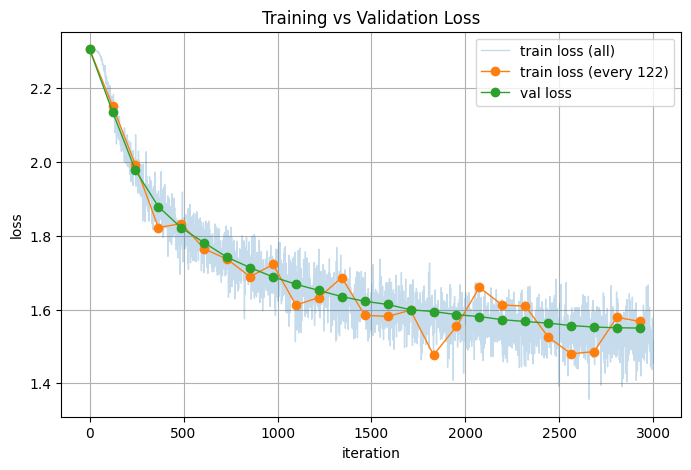

lr: 0.0003, reg: 0.25, hidden_size: 500, batch_size: 100
iteration 0 / 3000: loss 2.306382
iteration 100 / 3000: loss 2.166502
iteration 200 / 3000: loss 2.091174
iteration 300 / 3000: loss 1.966751
iteration 400 / 3000: loss 1.915822
iteration 500 / 3000: loss 1.878542
iteration 600 / 3000: loss 1.614058
iteration 700 / 3000: loss 1.822345
iteration 800 / 3000: loss 1.818235
iteration 900 / 3000: loss 1.581665
iteration 1000 / 3000: loss 1.614227
iteration 1100 / 3000: loss 1.616183
iteration 1200 / 3000: loss 1.681609
iteration 1300 / 3000: loss 1.653620
iteration 1400 / 3000: loss 1.578850
iteration 1500 / 3000: loss 1.681695
iteration 1600 / 3000: loss 1.554245
iteration 1700 / 3000: loss 1.450106
iteration 1800 / 3000: loss 1.734664
iteration 1900 / 3000: loss 1.545173
iteration 2000 / 3000: loss 1.531846
iteration 2100 / 3000: loss 1.401888
iteration 2200 / 3000: loss 1.533750
iteration 2300 / 3000: loss 1.376899
iteration 2400 / 3000: loss 1.561268
iteration 2500 / 3000: loss 1.

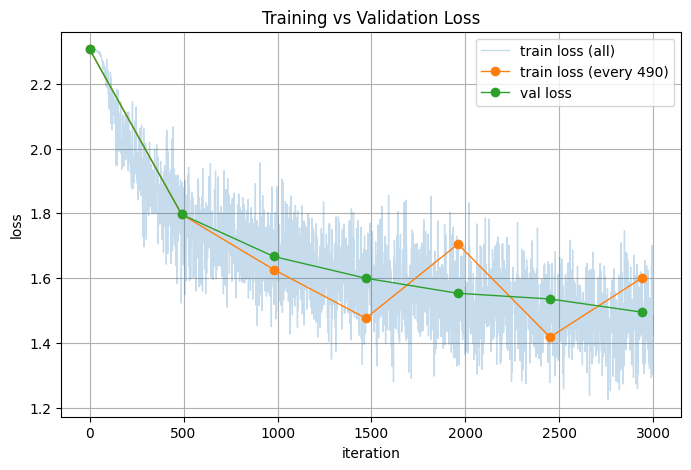

lr: 0.0003, reg: 0.25, hidden_size: 500, batch_size: 200
iteration 0 / 3000: loss 2.306431
iteration 100 / 3000: loss 2.212679
iteration 200 / 3000: loss 2.059353
iteration 300 / 3000: loss 1.893397
iteration 400 / 3000: loss 1.815500
iteration 500 / 3000: loss 1.800824
iteration 600 / 3000: loss 1.756287
iteration 700 / 3000: loss 1.844204
iteration 800 / 3000: loss 1.603952
iteration 900 / 3000: loss 1.852123
iteration 1000 / 3000: loss 1.650675
iteration 1100 / 3000: loss 1.686310
iteration 1200 / 3000: loss 1.490759
iteration 1300 / 3000: loss 1.565661
iteration 1400 / 3000: loss 1.647552
iteration 1500 / 3000: loss 1.680563
iteration 1600 / 3000: loss 1.501615
iteration 1700 / 3000: loss 1.576771
iteration 1800 / 3000: loss 1.583683
iteration 1900 / 3000: loss 1.641951
iteration 2000 / 3000: loss 1.594736
iteration 2100 / 3000: loss 1.452024
iteration 2200 / 3000: loss 1.503589
iteration 2300 / 3000: loss 1.453215
iteration 2400 / 3000: loss 1.520408
iteration 2500 / 3000: loss 1.

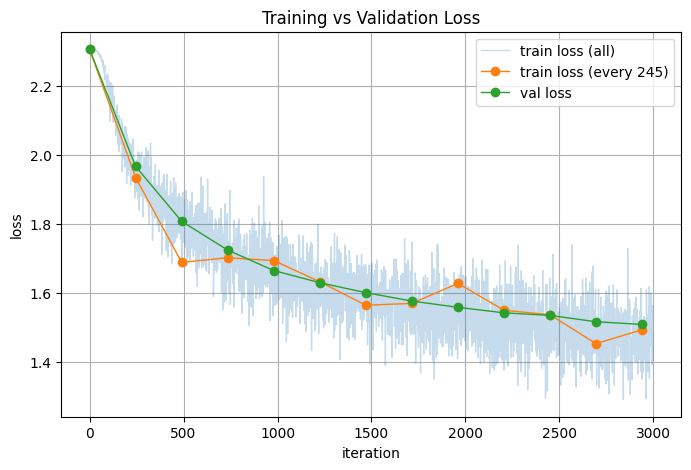

lr: 0.0003, reg: 0.25, hidden_size: 500, batch_size: 400
iteration 0 / 3000: loss 2.306394
iteration 100 / 3000: loss 2.197166
iteration 200 / 3000: loss 1.971993
iteration 300 / 3000: loss 1.870370
iteration 400 / 3000: loss 1.792572
iteration 500 / 3000: loss 1.834770
iteration 600 / 3000: loss 1.719514
iteration 700 / 3000: loss 1.759087
iteration 800 / 3000: loss 1.700765
iteration 900 / 3000: loss 1.641643
iteration 1000 / 3000: loss 1.668702
iteration 1100 / 3000: loss 1.607777
iteration 1200 / 3000: loss 1.607172
iteration 1300 / 3000: loss 1.618005
iteration 1400 / 3000: loss 1.507908
iteration 1500 / 3000: loss 1.641557
iteration 1600 / 3000: loss 1.590630
iteration 1700 / 3000: loss 1.572713
iteration 1800 / 3000: loss 1.540415
iteration 1900 / 3000: loss 1.587927
iteration 2000 / 3000: loss 1.555719
iteration 2100 / 3000: loss 1.481624
iteration 2200 / 3000: loss 1.557211
iteration 2300 / 3000: loss 1.610746
iteration 2400 / 3000: loss 1.616527
iteration 2500 / 3000: loss 1.

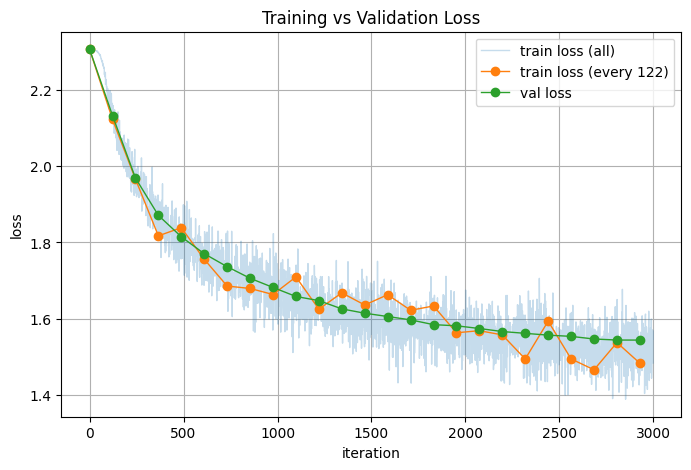

lr: 0.0003, reg: 0.5, hidden_size: 200, batch_size: 100
iteration 0 / 3000: loss 2.305700
iteration 100 / 3000: loss 2.210968
iteration 200 / 3000: loss 1.987437
iteration 300 / 3000: loss 1.806890
iteration 400 / 3000: loss 1.915045
iteration 500 / 3000: loss 1.864734
iteration 600 / 3000: loss 1.919485
iteration 700 / 3000: loss 1.693217
iteration 800 / 3000: loss 1.776808
iteration 900 / 3000: loss 1.674184
iteration 1000 / 3000: loss 1.707607
iteration 1100 / 3000: loss 1.684031
iteration 1200 / 3000: loss 1.672490
iteration 1300 / 3000: loss 1.717121
iteration 1400 / 3000: loss 1.525189
iteration 1500 / 3000: loss 1.509884
iteration 1600 / 3000: loss 1.654035
iteration 1700 / 3000: loss 1.677182
iteration 1800 / 3000: loss 1.610230
iteration 1900 / 3000: loss 1.498419
iteration 2000 / 3000: loss 1.605557
iteration 2100 / 3000: loss 1.570386
iteration 2200 / 3000: loss 1.478654
iteration 2300 / 3000: loss 1.578606
iteration 2400 / 3000: loss 1.537952
iteration 2500 / 3000: loss 1.4

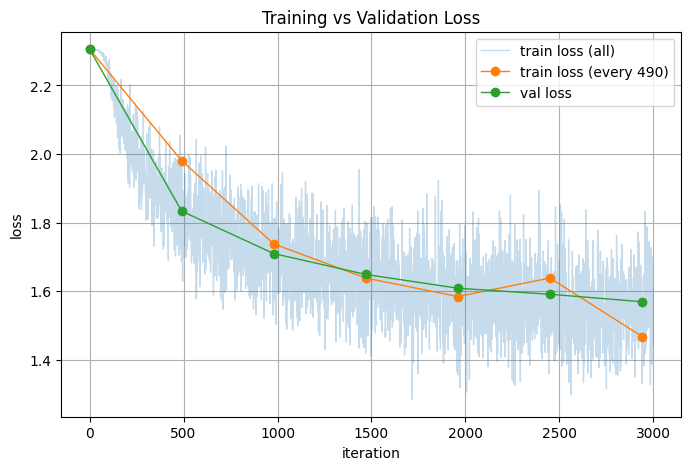

lr: 0.0003, reg: 0.5, hidden_size: 200, batch_size: 200
iteration 0 / 3000: loss 2.305622
iteration 100 / 3000: loss 2.203802
iteration 200 / 3000: loss 2.006069
iteration 300 / 3000: loss 1.983965
iteration 400 / 3000: loss 1.831456
iteration 500 / 3000: loss 1.881134
iteration 600 / 3000: loss 1.785918
iteration 700 / 3000: loss 1.806415
iteration 800 / 3000: loss 1.765441
iteration 900 / 3000: loss 1.782283
iteration 1000 / 3000: loss 1.773676
iteration 1100 / 3000: loss 1.595786
iteration 1200 / 3000: loss 1.710900
iteration 1300 / 3000: loss 1.604779
iteration 1400 / 3000: loss 1.658155
iteration 1500 / 3000: loss 1.632992
iteration 1600 / 3000: loss 1.692796
iteration 1700 / 3000: loss 1.626055
iteration 1800 / 3000: loss 1.711672
iteration 1900 / 3000: loss 1.607819
iteration 2000 / 3000: loss 1.598330
iteration 2100 / 3000: loss 1.635743
iteration 2200 / 3000: loss 1.603283
iteration 2300 / 3000: loss 1.512875
iteration 2400 / 3000: loss 1.716720
iteration 2500 / 3000: loss 1.6

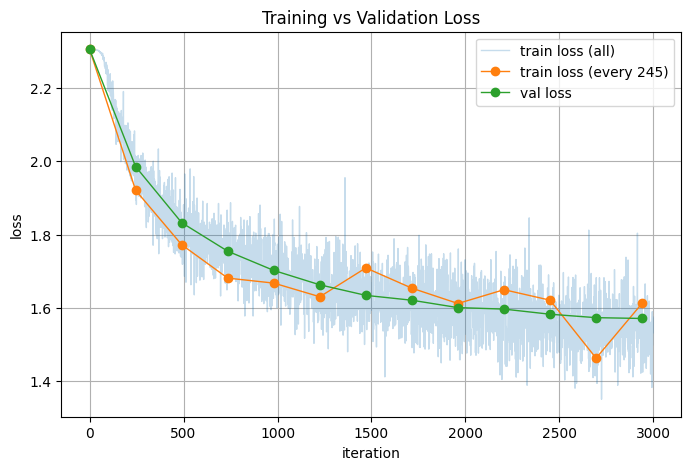

lr: 0.0003, reg: 0.5, hidden_size: 200, batch_size: 400
iteration 0 / 3000: loss 2.305697
iteration 100 / 3000: loss 2.232824
iteration 200 / 3000: loss 2.064721
iteration 300 / 3000: loss 1.937360
iteration 400 / 3000: loss 1.796569
iteration 500 / 3000: loss 1.847196
iteration 600 / 3000: loss 1.796108
iteration 700 / 3000: loss 1.757322
iteration 800 / 3000: loss 1.760814
iteration 900 / 3000: loss 1.743283
iteration 1000 / 3000: loss 1.689983
iteration 1100 / 3000: loss 1.685487
iteration 1200 / 3000: loss 1.702272
iteration 1300 / 3000: loss 1.623060
iteration 1400 / 3000: loss 1.714143
iteration 1500 / 3000: loss 1.630385
iteration 1600 / 3000: loss 1.572240
iteration 1700 / 3000: loss 1.608620
iteration 1800 / 3000: loss 1.630169
iteration 1900 / 3000: loss 1.581321
iteration 2000 / 3000: loss 1.623343
iteration 2100 / 3000: loss 1.620705
iteration 2200 / 3000: loss 1.604691
iteration 2300 / 3000: loss 1.579918
iteration 2400 / 3000: loss 1.488057
iteration 2500 / 3000: loss 1.6

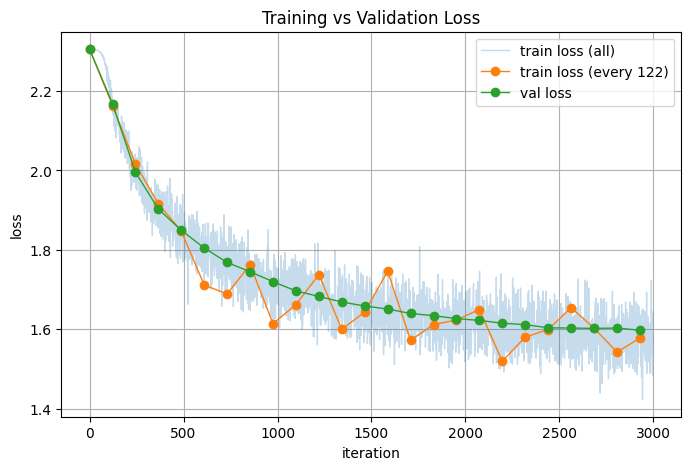

lr: 0.0003, reg: 0.5, hidden_size: 300, batch_size: 100
iteration 0 / 3000: loss 2.307255
iteration 100 / 3000: loss 2.252461
iteration 200 / 3000: loss 2.052572
iteration 300 / 3000: loss 1.857332
iteration 400 / 3000: loss 1.911923
iteration 500 / 3000: loss 1.854430
iteration 600 / 3000: loss 1.842317
iteration 700 / 3000: loss 1.768327
iteration 800 / 3000: loss 1.712521
iteration 900 / 3000: loss 1.757791
iteration 1000 / 3000: loss 1.658836
iteration 1100 / 3000: loss 1.644986
iteration 1200 / 3000: loss 1.601171
iteration 1300 / 3000: loss 1.603750
iteration 1400 / 3000: loss 1.615835
iteration 1500 / 3000: loss 1.515985
iteration 1600 / 3000: loss 1.453264
iteration 1700 / 3000: loss 1.498431
iteration 1800 / 3000: loss 1.527020
iteration 1900 / 3000: loss 1.542577
iteration 2000 / 3000: loss 1.629058
iteration 2100 / 3000: loss 1.520389
iteration 2200 / 3000: loss 1.466762
iteration 2300 / 3000: loss 1.502336
iteration 2400 / 3000: loss 1.480314
iteration 2500 / 3000: loss 1.4

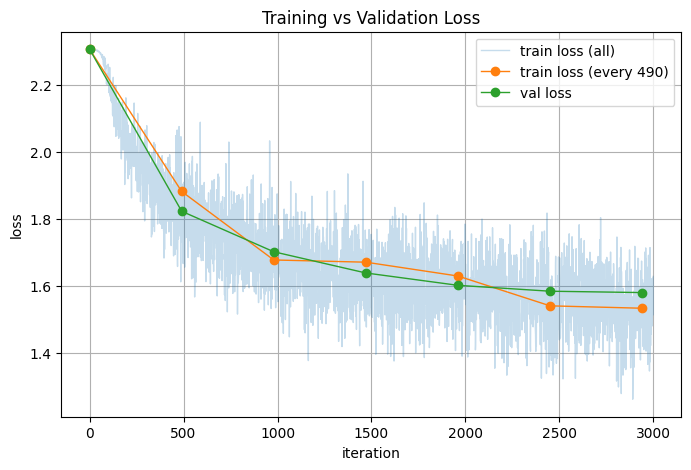

lr: 0.0003, reg: 0.5, hidden_size: 300, batch_size: 200
iteration 0 / 3000: loss 2.307169
iteration 100 / 3000: loss 2.172282
iteration 200 / 3000: loss 2.046968
iteration 300 / 3000: loss 1.869965
iteration 400 / 3000: loss 1.844410
iteration 500 / 3000: loss 1.741594
iteration 600 / 3000: loss 1.758841
iteration 700 / 3000: loss 1.755165
iteration 800 / 3000: loss 1.655057
iteration 900 / 3000: loss 1.654369
iteration 1000 / 3000: loss 1.622522
iteration 1100 / 3000: loss 1.731321
iteration 1200 / 3000: loss 1.542344
iteration 1300 / 3000: loss 1.601403
iteration 1400 / 3000: loss 1.631373
iteration 1500 / 3000: loss 1.573422
iteration 1600 / 3000: loss 1.593217
iteration 1700 / 3000: loss 1.587688
iteration 1800 / 3000: loss 1.623357
iteration 1900 / 3000: loss 1.533563
iteration 2000 / 3000: loss 1.559763
iteration 2100 / 3000: loss 1.547352
iteration 2200 / 3000: loss 1.665056
iteration 2300 / 3000: loss 1.593127
iteration 2400 / 3000: loss 1.491142
iteration 2500 / 3000: loss 1.5

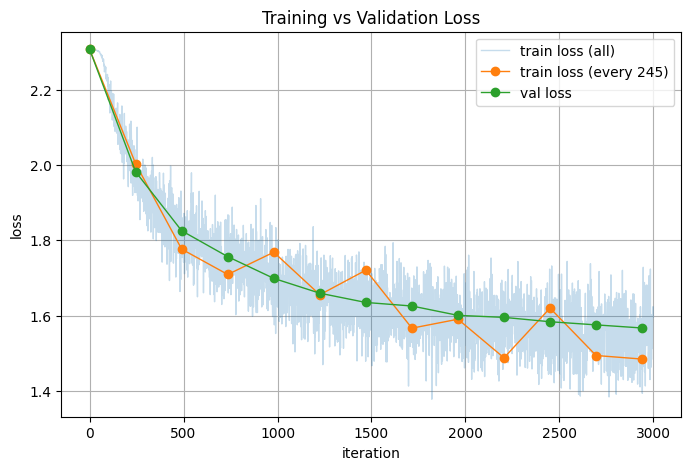

lr: 0.0003, reg: 0.5, hidden_size: 300, batch_size: 400
iteration 0 / 3000: loss 2.307164
iteration 100 / 3000: loss 2.194336
iteration 200 / 3000: loss 2.012833
iteration 300 / 3000: loss 1.998310
iteration 400 / 3000: loss 1.825950
iteration 500 / 3000: loss 1.841785
iteration 600 / 3000: loss 1.807104
iteration 700 / 3000: loss 1.752521
iteration 800 / 3000: loss 1.761757
iteration 900 / 3000: loss 1.709547
iteration 1000 / 3000: loss 1.754007
iteration 1100 / 3000: loss 1.665296
iteration 1200 / 3000: loss 1.793082
iteration 1300 / 3000: loss 1.673710
iteration 1400 / 3000: loss 1.634324
iteration 1500 / 3000: loss 1.582628
iteration 1600 / 3000: loss 1.663235
iteration 1700 / 3000: loss 1.621248
iteration 1800 / 3000: loss 1.603178
iteration 1900 / 3000: loss 1.640587
iteration 2000 / 3000: loss 1.600734
iteration 2100 / 3000: loss 1.542415
iteration 2200 / 3000: loss 1.502599
iteration 2300 / 3000: loss 1.663482
iteration 2400 / 3000: loss 1.624346
iteration 2500 / 3000: loss 1.6

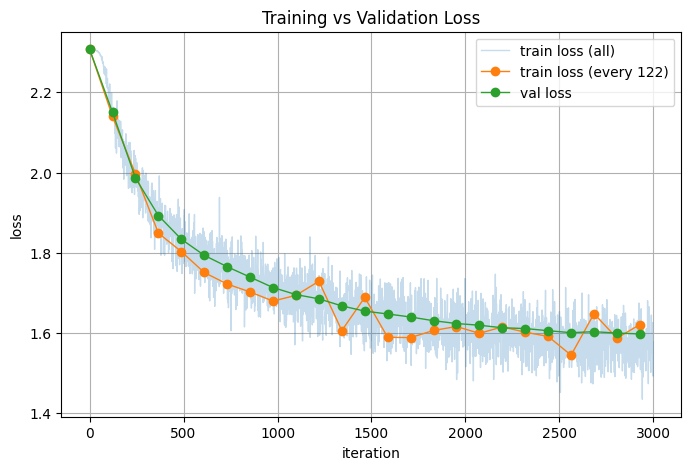

lr: 0.0003, reg: 0.5, hidden_size: 400, batch_size: 100
iteration 0 / 3000: loss 2.308842
iteration 100 / 3000: loss 2.233765
iteration 200 / 3000: loss 1.993121
iteration 300 / 3000: loss 1.941025
iteration 400 / 3000: loss 1.872908
iteration 500 / 3000: loss 1.836396
iteration 600 / 3000: loss 1.834851
iteration 700 / 3000: loss 1.808887
iteration 800 / 3000: loss 1.771089
iteration 900 / 3000: loss 1.583683
iteration 1000 / 3000: loss 1.684862
iteration 1100 / 3000: loss 1.642236
iteration 1200 / 3000: loss 1.564479
iteration 1300 / 3000: loss 1.537558
iteration 1400 / 3000: loss 1.633247
iteration 1500 / 3000: loss 1.561973
iteration 1600 / 3000: loss 1.615049
iteration 1700 / 3000: loss 1.619354
iteration 1800 / 3000: loss 1.539922
iteration 1900 / 3000: loss 1.598332
iteration 2000 / 3000: loss 1.586687
iteration 2100 / 3000: loss 1.557990
iteration 2200 / 3000: loss 1.340003
iteration 2300 / 3000: loss 1.532072
iteration 2400 / 3000: loss 1.497734
iteration 2500 / 3000: loss 1.5

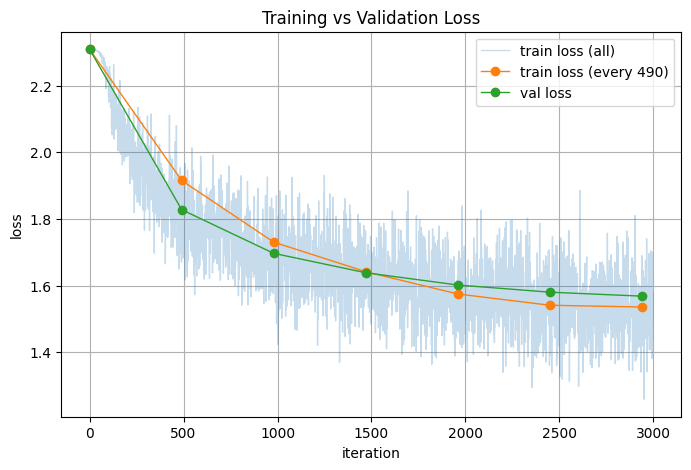

lr: 0.0003, reg: 0.5, hidden_size: 400, batch_size: 200
iteration 0 / 3000: loss 2.308806
iteration 100 / 3000: loss 2.203922
iteration 200 / 3000: loss 2.001226
iteration 300 / 3000: loss 1.930620
iteration 400 / 3000: loss 1.918122
iteration 500 / 3000: loss 1.796007
iteration 600 / 3000: loss 1.719957
iteration 700 / 3000: loss 1.765076
iteration 800 / 3000: loss 1.730032
iteration 900 / 3000: loss 1.751530
iteration 1000 / 3000: loss 1.736899
iteration 1100 / 3000: loss 1.637018
iteration 1200 / 3000: loss 1.601356
iteration 1300 / 3000: loss 1.716903
iteration 1400 / 3000: loss 1.679478
iteration 1500 / 3000: loss 1.548874
iteration 1600 / 3000: loss 1.687932
iteration 1700 / 3000: loss 1.460821
iteration 1800 / 3000: loss 1.629745
iteration 1900 / 3000: loss 1.533743
iteration 2000 / 3000: loss 1.631059
iteration 2100 / 3000: loss 1.541646
iteration 2200 / 3000: loss 1.562743
iteration 2300 / 3000: loss 1.579866
iteration 2400 / 3000: loss 1.507573
iteration 2500 / 3000: loss 1.5

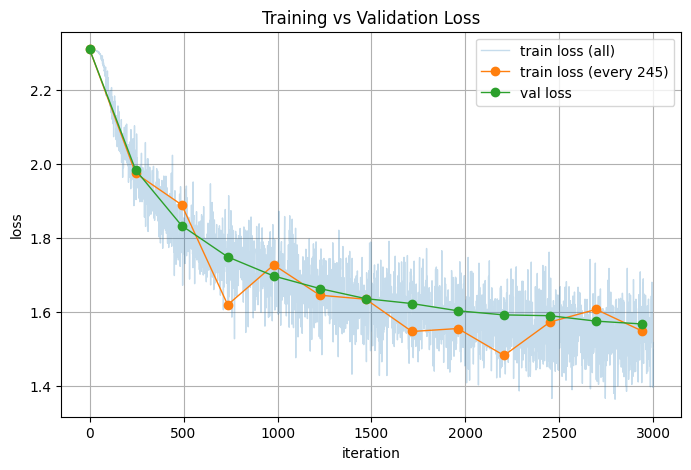

lr: 0.0003, reg: 0.5, hidden_size: 400, batch_size: 400
iteration 0 / 3000: loss 2.308757
iteration 100 / 3000: loss 2.201920
iteration 200 / 3000: loss 2.020940
iteration 300 / 3000: loss 1.922041
iteration 400 / 3000: loss 1.842773
iteration 500 / 3000: loss 1.790382
iteration 600 / 3000: loss 1.892803
iteration 700 / 3000: loss 1.758517
iteration 800 / 3000: loss 1.704698
iteration 900 / 3000: loss 1.688627
iteration 1000 / 3000: loss 1.634166
iteration 1100 / 3000: loss 1.684507
iteration 1200 / 3000: loss 1.677953
iteration 1300 / 3000: loss 1.629037
iteration 1400 / 3000: loss 1.643866
iteration 1500 / 3000: loss 1.683413
iteration 1600 / 3000: loss 1.630016
iteration 1700 / 3000: loss 1.693873
iteration 1800 / 3000: loss 1.666423
iteration 1900 / 3000: loss 1.661715
iteration 2000 / 3000: loss 1.660499
iteration 2100 / 3000: loss 1.508248
iteration 2200 / 3000: loss 1.624637
iteration 2300 / 3000: loss 1.581368
iteration 2400 / 3000: loss 1.666407
iteration 2500 / 3000: loss 1.5

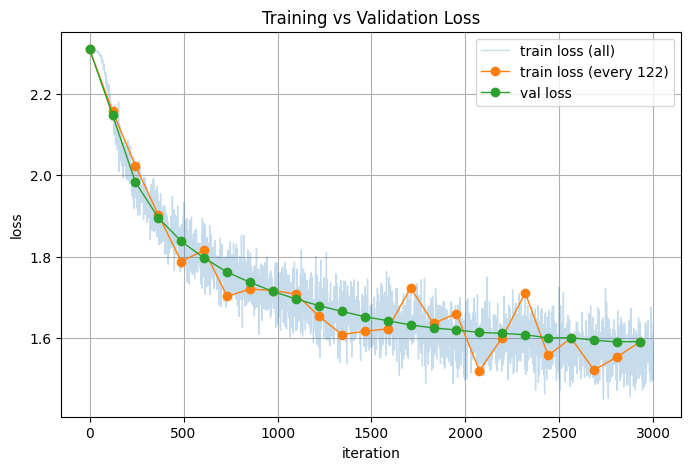

lr: 0.0003, reg: 0.5, hidden_size: 500, batch_size: 100
iteration 0 / 3000: loss 2.310248
iteration 100 / 3000: loss 2.215649
iteration 200 / 3000: loss 1.978205
iteration 300 / 3000: loss 2.002898
iteration 400 / 3000: loss 1.791684
iteration 500 / 3000: loss 1.793110
iteration 600 / 3000: loss 1.898014
iteration 700 / 3000: loss 1.811305
iteration 800 / 3000: loss 1.555974
iteration 900 / 3000: loss 1.593861
iteration 1000 / 3000: loss 1.741946
iteration 1100 / 3000: loss 1.623825
iteration 1200 / 3000: loss 1.664851
iteration 1300 / 3000: loss 1.813848
iteration 1400 / 3000: loss 1.518126
iteration 1500 / 3000: loss 1.723259
iteration 1600 / 3000: loss 1.695052
iteration 1700 / 3000: loss 1.559741
iteration 1800 / 3000: loss 1.577107
iteration 1900 / 3000: loss 1.558260
iteration 2000 / 3000: loss 1.659210
iteration 2100 / 3000: loss 1.568508
iteration 2200 / 3000: loss 1.650376
iteration 2300 / 3000: loss 1.547420
iteration 2400 / 3000: loss 1.610305
iteration 2500 / 3000: loss 1.4

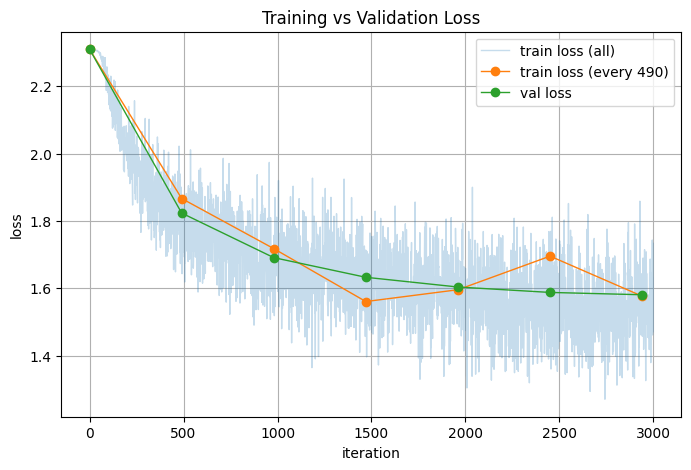

lr: 0.0003, reg: 0.5, hidden_size: 500, batch_size: 200
iteration 0 / 3000: loss 2.310288
iteration 100 / 3000: loss 2.221114
iteration 200 / 3000: loss 1.965899
iteration 300 / 3000: loss 1.793731
iteration 400 / 3000: loss 1.743593
iteration 500 / 3000: loss 1.893550
iteration 600 / 3000: loss 1.680084
iteration 700 / 3000: loss 1.742648
iteration 800 / 3000: loss 1.666888
iteration 900 / 3000: loss 1.690259
iteration 1000 / 3000: loss 1.746829
iteration 1100 / 3000: loss 1.662567
iteration 1200 / 3000: loss 1.643385
iteration 1300 / 3000: loss 1.690434
iteration 1400 / 3000: loss 1.678824
iteration 1500 / 3000: loss 1.587182
iteration 1600 / 3000: loss 1.569336
iteration 1700 / 3000: loss 1.558333


In [ ]:
best_net = None # store the best model into this 

#################################################################################
# Task 4.5                                                                      #
# TODO: Tune hyperparameters using the validation set. Store your best trained  #
# model in best_net.                                                            #
#                                                                               #
# To help debug your network, it may help to use visualizations similar to the  #
# ones we used above; these visualizations will have significant qualitative    #
# differences from the ones we saw above for the poorly tuned network.          #
#                                                                               #
# Tweaking hyperparameters by hand can be fun, but you might find it useful to  #
# write code to sweep through possible combinations of hyperparameters          #
# automatically like we did on the previous exercises.                          #
#################################################################################

input_size = 32 * 32 * 3
num_classes = 10
std = 1e-4
num_iters = 5000
learning_rate_decay = 0.95

learning_rates = [3e-4, 5e-4, 7e-4, 1e-3]
regularization_strengths = [0.05, 0.1, 0.15, 0.2]
hidden_sizes = [200, 400]
batch_sizes = [100]

best_val = -1
current_results = []

for lr in learning_rates:
    for reg in regularization_strengths:
        for hidden_size in hidden_sizes:
            for batch_size in batch_sizes:

                # Initialize a new network for each set of hyperparameters
                print(f"lr: {lr}, reg: {reg}, hidden_size: {hidden_size}, batch_size: {batch_size}")

                key = task45_cache_key(lr, reg, hidden_size, batch_size, std, num_iters, learning_rate_decay)

                if key in task45_model_cache:
                    result = task45_model_cache[key]
                    net = result['net']
                    stats = result['stats']
                    val_acc = result['val_acc']
                else:
                    net = init_toy_model(input_size, hidden_size, num_classes, std)

                    stats = net.train(X_train, y_train, X_val, y_val,
                                num_iters=num_iters, batch_size=batch_size,
                                learning_rate=lr, learning_rate_decay=learning_rate_decay,
                                reg=reg, verbose=True)

                    # Predict on the validation set
                    val_predictions = net.predict(X_val)
                    val_acc = torch.mean((val_predictions == y_val).float()).item()
                    result = {
                        'key': key,
                        'params': {
                            'lr': lr,
                            'reg': reg,
                            'hidden_size': hidden_size,
                            'batch_size': batch_size,
                            'std': std,
                            'num_iters': num_iters,
                            'learning_rate_decay': learning_rate_decay,
                        },
                        'net': net,
                        'stats': stats,
                        'val_acc': val_acc,
                    }
                    task45_model_cache[key] = result
                    task45_sweep_history.append(result)

                print('Validation accuracy: ', val_acc)
                print(f'lr: {lr:.1e}, reg: {reg:.2f}, hidden: {hidden_size}, batch: {batch_size}, val_acc: {val_acc:.4f}')
                plot_train_val_loss(stats, iterations_per_epoch=max(X_train.shape[0] // batch_size, 1))
                current_results.append(result)

                if val_acc > best_val:
                    best_val = val_acc
                    best_net = net

#################################################################################
#                               END OF YOUR CODE                                #
#################################################################################

globals()['best_net'] = best_net
globals()['task45_best_result'] = max(current_results, key=lambda x: x['val_acc'])
task45_show_summary(current_results, title='Task 4.5 sweep summary (current grid)')

hyperparam_lists = [learning_rates, regularization_strengths, hidden_sizes, batch_sizes]
assert all(len(lst) > 0 for lst in hyperparam_lists), (
    'Task 4.5 failed: all hyperparameter lists must be non-empty.'
)
assert any(len(lst) > 1 for lst in hyperparam_lists), (
    'Task 4.5 failed: at least one hyperparameter list must contain more than one value.'
)
print('Task 4.5 setup passed: hyperparameter lists are non-empty and include a sweep dimension.')
assert best_net is not None, 'Task 4.5 failed: best_net was not set.'
print(f'Task 4.5 passed: best model selected with validation accuracy {best_val:.4f}.')

### Task 4.6
Describe how different hyperparameters seem to affect the result and what might be their interactions. Which are the most important and which are less important? Be thorough and mention all hyperparameters you tried. Describe what you see, not general case from textbook.

**Your answer:** 

In [ ]:
# visualize the weights of the best network
show_net_weights(best_net)

# Run on the test set
When you are done experimenting, you should evaluate your final trained network on the test set; you should get above 48%.

### Bonus Task (up to 5 pts):
**We will give you extra bonus point for every 1% of accuracy above 52%. (up to a maximum 5 bonus points)**

In [ ]:
test_acc = (best_net.predict(X_test) == y_test).to(torch.float64).mean().item()
print('Test accuracy: ', test_acc)
assert test_acc > 0.48, f'Test-set requirement failed: accuracy too low ({test_acc:.4f} <= 0.48)'
print(f'Test-set check passed: accuracy is above 48% ({test_acc:.4f}).')

above_52_pct_points = max(0.0, (test_acc - 0.52) * 100.0)
bonus_points = min(5.0, above_52_pct_points)
print(f'Above 52% by: {above_52_pct_points:.2f} percentage points.')
print(f'Bonus points (capped at 5): {bonus_points:.2f}')
